In [ ]:
import torch
import torch.nn as nn
import glob
import os
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)
from transformers import (
    AutoTokenizer,
    PreTrainedModel,
    PretrainedConfig
)

# This assumes 'utils.py' is in the same directory
from utils import SegmentFromFile

# ==========================================
# 1. DEFINE THE TITANS ARCHITECTURE (MUST MATCH TRAINING SCRIPT EXACTLY)
# ==========================================

class TitansConfig(PretrainedConfig):
    model_type = "titans"
    def __init__(
        self,
        vocab_size=30522,
        hidden_size=256,
        num_hidden_layers=4,
        num_attention_heads=4,
        intermediate_size=1024,
        num_persistent_tokens=16,
        segment_len=128,
        num_labels=2,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_hidden_layers = num_hidden_layers
        self.num_attention_heads = num_attention_heads
        self.intermediate_size = intermediate_size
        self.num_persistent_tokens = num_persistent_tokens
        self.segment_len = segment_len
        self.num_labels = num_labels

class NeuralMemory(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.memory_cell = nn.GRUCell(input_dim, hidden_dim)
    
    def forward(self, x, h_prev):
        return self.memory_cell(x, h_prev)

class TitansMACClassifier(PreTrainedModel):
    config_class = TitansConfig

    def __init__(self, config):
        super().__init__(config)
        self.config = config
        self.num_labels = config.num_labels
        
        self.embedding = nn.Embedding(config.vocab_size, config.hidden_size)
        self.persistent_memory = nn.Parameter(torch.randn(config.num_persistent_tokens, config.hidden_size))
        self.neural_memory = NeuralMemory(config.hidden_size, config.hidden_size)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.hidden_size, 
            nhead=config.num_attention_heads, 
            dim_feedforward=config.intermediate_size,
            batch_first=True,
            norm_first=True
        )
        self.core_attention = nn.TransformerEncoder(encoder_layer, num_layers=config.num_hidden_layers)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
        
    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        x = self.embedding(input_ids)
        batch_size, seq_len, hidden_size = x.shape
        
        remainder = seq_len % self.config.segment_len
        if remainder > 0:
            pad_len = self.config.segment_len - remainder
            padding = torch.zeros(batch_size, pad_len, hidden_size, device=x.device)
            x = torch.cat([x, padding], dim=1)
        
        segments = x.split(self.config.segment_len, dim=1)
        memory_state = torch.zeros(batch_size, hidden_size, device=x.device)
        
        for segment in segments:
            context = memory_state.unsqueeze(1)
            persistent_batch = self.persistent_memory.unsqueeze(0).expand(batch_size, -1, -1)
            combined_input = torch.cat([persistent_batch, context, segment], dim=1)
            
            core_out = self.core_attention(combined_input)
            segment_out = core_out[:, -self.config.segment_len:, :]
            
            segment_summary = segment_out.mean(dim=1)
            memory_state = self.neural_memory(segment_summary, memory_state)
            
        logits = self.classifier(memory_state)
        
        # Return a simple object or dictionary compatible with standard inference
        from transformers.modeling_outputs import SequenceClassifierOutput
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return SequenceClassifierOutput(loss=loss, logits=logits)

# ==========================================
# 2. EVALUATION FUNCTION
# ==========================================

def evaluate_model(model_path, validation_data_directory, time_gap, device="cuda"):
    print(f"\n--- Starting Evaluation of Model: {model_path} ---")
    if not os.path.isdir(model_path):
        raise FileNotFoundError(f"Model directory not found at: {model_path}")

    # --- LOAD TOKENIZER ---
    # We try to load from the checkpoint, or fallback to mobilebert if it wasn't saved perfectly
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_path)
    except:
        print("Tokenizer not found in checkpoint, loading default MobileBERT tokenizer...")
        tokenizer = AutoTokenizer.from_pretrained("google/mobilebert-uncased")

    # --- LOAD CUSTOM MODEL ---
    print("Loading Custom Titans Model...")
    # KEY CHANGE: We use the custom class, not AutoModel
    model = TitansMACClassifier.from_pretrained(model_path)
    model.to(device)
    model.eval()

    # --- PROCESS DATA ---
    print(f"Loading validation data from: {validation_data_directory}")
    all_chunks = []
    all_labels = []

    csv_files = glob.glob(os.path.join(validation_data_directory, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {validation_data_directory}")

    for file_path in tqdm(csv_files, desc="Processing validation files"):
        filename = os.path.basename(file_path)
        chunks, labels = SegmentFromFile(validation_data_directory, filename, time_gap=time_gap)
        all_chunks.extend(chunks)
        all_labels.extend(labels)

    print(f"Total validation segments loaded: {len(all_chunks)}")

    def format_chunk_to_string(chunk):
        tokens = []
        for pair in chunk:
            token1 = f"T{int(pair[0])}"
            token2 = f"G{int(pair[1])}"
            tokens.append(token1)
            tokens.append(token2)
        return " ".join(tokens)

    texts = [format_chunk_to_string(chunk) for chunk in tqdm(all_chunks, desc="Formatting segments")]

    # --- INFERENCE ---
    print("Running inference on validation data...")
    batch_size = 32  # Can likely increase batch size as Titans is lighter than BERT
    all_preds = []
    
    num_batches = (len(texts) + batch_size - 1) // batch_size
    for i in tqdm(range(0, len(texts), batch_size), total=num_batches, desc="Inference"):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)

        all_preds.extend(preds.cpu().numpy())

    # --- METRICS ---
    print("\nCalculating metrics...")
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    print("\n=== Validation Results ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")

    print("\n=== Confusion Matrix ===")
    tn, fp, fn, tp = cm.ravel()
    print(f"Predicted Negative | Predicted Positive")
    print(f"Actual Negative: {tn:<17d}| {fp:<17d}")
    print(f"Actual Positive: {fn:<17d}| {tp:<17d}")
    print("=" * 30)

    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

In [77]:
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainGen/titans-mac-can-classifier"

Train on Kia

In [78]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Lower Low"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainGen/titans-mac-can-classifier ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainGen/titans-mac-can-classifier ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Lower Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.09it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8584.30it/s]


Running inference on validation data...


Inference: 100%|██████████| 105/105 [00:02<00:00, 36.67it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9131
F1 Score:  0.8738
Precision: 0.7948
Recall:    0.9701

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2052             | 260              
Actual Positive: 31               | 1007             


{'accuracy': 0.913134328358209,
 'f1': 0.8737527114967462,
 'precision': 0.7947908445146015,
 'recall': 0.9701348747591522}

In [71]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Low"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainGen/titans-mac-can-classifier ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainGen/titans-mac-can-classifier ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.10it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8509.36it/s]


Running inference on validation data...


Inference: 100%|██████████| 105/105 [00:02<00:00, 36.68it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9221
F1 Score:  0.8885
Precision: 0.8000
Recall:    0.9990

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2049             | 260              
Actual Positive: 1                | 1040             


{'accuracy': 0.922089552238806,
 'f1': 0.888509184109355,
 'precision': 0.8,
 'recall': 0.9990393852065321}

In [ ]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Medium"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainGen/titans-mac-can-classifier ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainGen/titans-mac-can-classifier ---
Loading Custom Titans Model...
Loading validation data from: SFTSrc/titans/OnnxModels/TrainGenOnnx


/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


FileNotFoundError: No CSV files found in: SFTSrc/titans/OnnxModels/TrainGenOnnx

In [73]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Random"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainGen/titans-mac-can-classifier ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainGen/titans-mac-can-classifier ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Random


Processing validation files:   0%|          | 0/4 [00:00<?, ?it/s]

Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.02it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8455.68it/s]


Running inference on validation data...


Inference: 100%|██████████| 105/105 [00:02<00:00, 36.44it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9224
F1 Score:  0.8890
Precision: 0.8002
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2049             | 260              
Actual Positive: 0                | 1041             


{'accuracy': 0.9223880597014925,
 'f1': 0.8889837745516652,
 'precision': 0.8001537279016141,
 'recall': 1.0}

In [10]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/High"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3356 ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3356 ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/High


Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.37s/it]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 7903.55it/s]


Running inference on validation data...


Inference: 100%|██████████| 105/105 [00:04<00:00, 24.00it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9224
F1 Score:  0.8890
Precision: 0.8002
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2049             | 260              
Actual Positive: 0                | 1041             


{'accuracy': 0.9223880597014925,
 'f1': 0.8889837745516652,
 'precision': 0.8001537279016141,
 'recall': 1.0}

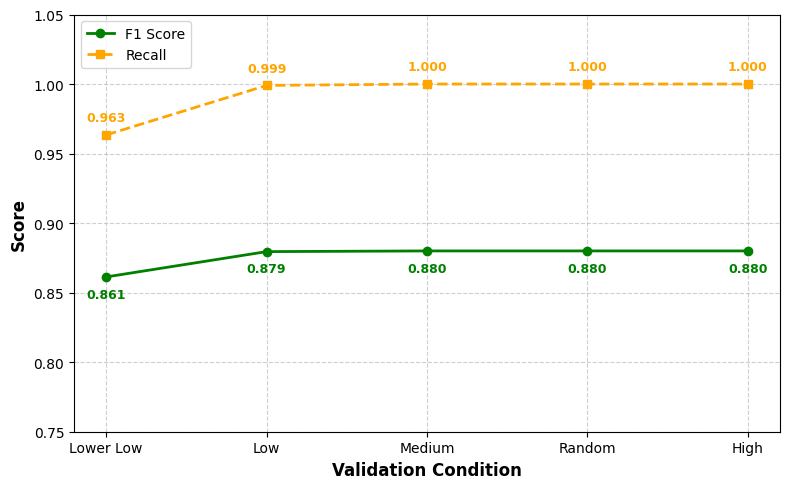

In [32]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.8613, 0.8795, 0.8800, 0.8800, 0.8800]
recalls =   [0.9634, 0.9990, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5))

# Plot both F1 and Recall with custom colors
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values with better spacing
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
    plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

In [60]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Lower Low"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Lower Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.03it/s]


Total validation segments loaded: 3385


Formatting segments: 100%|██████████| 3385/3385 [00:00<00:00, 8745.97it/s]


Running inference on validation data...


Inference: 100%|██████████| 106/106 [00:02<00:00, 36.85it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9513
F1 Score:  0.9245
Precision: 0.8899
Recall:    0.9619

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 125              
Actual Positive: 40               | 1010             


{'accuracy': 0.9512555391432792,
 'f1': 0.9244851258581236,
 'precision': 0.8898678414096917,
 'recall': 0.9619047619047619}

In [62]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Low"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.03it/s]


Total validation segments loaded: 3387


Formatting segments: 100%|██████████| 3387/3387 [00:00<00:00, 8741.71it/s]


Running inference on validation data...


Inference: 100%|██████████| 106/106 [00:02<00:00, 36.47it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9631
F1 Score:  0.9439
Precision: 0.8938
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 125              
Actual Positive: 0                | 1052             


{'accuracy': 0.9630941836433422,
 'f1': 0.9439210408254822,
 'precision': 0.8937977909940527,
 'recall': 1.0}

In [56]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Medium"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3322 ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3322 ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Medium


Processing validation files: 100%|██████████| 4/4 [00:04<00:00,  1.05s/it]


Total validation segments loaded: 3386


Formatting segments: 100%|██████████| 3386/3386 [00:00<00:00, 8339.71it/s]


Running inference on validation data...


Inference: 100%|██████████| 106/106 [00:04<00:00, 24.19it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9634
F1 Score:  0.9443
Precision: 0.8946
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 124              
Actual Positive: 0                | 1052             


{'accuracy': 0.9633786178381571,
 'f1': 0.9443447037701975,
 'precision': 0.8945578231292517,
 'recall': 1.0}

In [57]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Random"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3322 ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3322 ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Random


Processing validation files:   0%|          | 0/4 [00:00<?, ?it/s]

Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.02it/s]


Total validation segments loaded: 3386


Formatting segments: 100%|██████████| 3386/3386 [00:00<00:00, 8289.53it/s]


Running inference on validation data...


Inference: 100%|██████████| 106/106 [00:04<00:00, 24.08it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9634
F1 Score:  0.9443
Precision: 0.8946
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 124              
Actual Positive: 0                | 1052             


{'accuracy': 0.9633786178381571,
 'f1': 0.9443447037701975,
 'precision': 0.8945578231292517,
 'recall': 1.0}

In [58]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/High"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3322 ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3322 ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/High


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.00it/s]


Total validation segments loaded: 3387


Formatting segments: 100%|██████████| 3387/3387 [00:00<00:00, 8174.18it/s]


Running inference on validation data...


Inference: 100%|██████████| 106/106 [00:03<00:00, 27.16it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9631
F1 Score:  0.9439
Precision: 0.8938
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 125              
Actual Positive: 0                | 1052             


{'accuracy': 0.9630941836433422,
 'f1': 0.9439210408254822,
 'precision': 0.8937977909940527,
 'recall': 1.0}

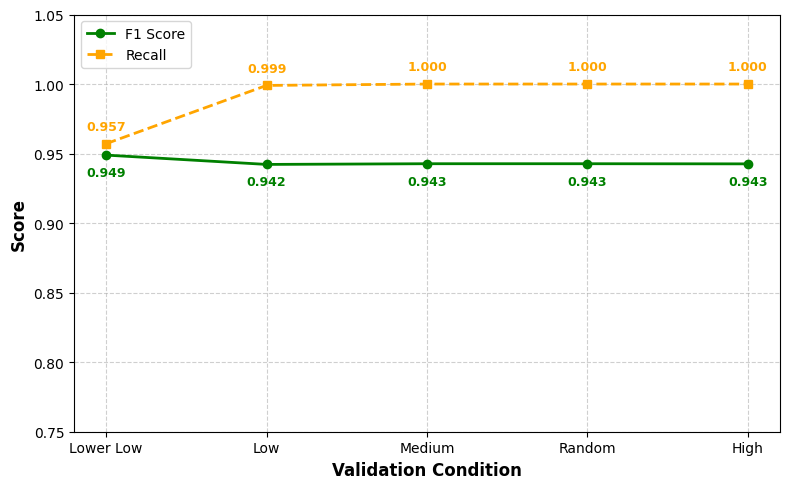

In [124]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.9489, 0.9422, 0.9427, 0.9427,  0.9426]
recalls =   [0.9571, 0.9990, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5))

# Plot both F1 and Recall with custom colors
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values with better spacing
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
    plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

In [35]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Lower Low"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3280 ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3280 ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Lower Low


Processing validation files:  25%|██▌       | 1/4 [00:00<00:02,  1.32it/s]/home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  50%|█████     | 2/4 [00:01<00:01,  1.39it/s]/home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:06<00:00,  1.51s/it]


Total validation segments loaded: 3287


Formatting segments: 100%|██████████| 3287/3287 [00:00<00:00, 8288.68it/s]


Running inference on validation data...


Inference: 100%|██████████| 103/103 [00:04<00:00, 24.42it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9909
F1 Score:  0.9851
Precision: 0.9970
Recall:    0.9735

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 3                
Actual Positive: 27               | 993              


{'accuracy': 0.9908731365987222,
 'f1': 0.9851190476190477,
 'precision': 0.9969879518072289,
 'recall': 0.9735294117647059}

In [36]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Low"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3280 ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3280 ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Low


Processing validation files:  50%|█████     | 2/4 [00:01<00:01,  1.64it/s]/home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.43s/it]


Total validation segments loaded: 3287


Formatting segments: 100%|██████████| 3287/3287 [00:00<00:00, 8210.44it/s]


Running inference on validation data...


Inference: 100%|██████████| 103/103 [00:04<00:00, 24.41it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9991
F1 Score:  0.9985
Precision: 0.9971
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 3                
Actual Positive: 0                | 1020             


{'accuracy': 0.9990873136598722,
 'f1': 0.9985315712187959,
 'precision': 0.9970674486803519,
 'recall': 1.0}

In [37]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Medium"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3280 ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3280 ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Medium


Processing validation files:  75%|███████▌  | 3/4 [00:02<00:00,  1.51it/s]/home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.39s/it]


Total validation segments loaded: 3287


Formatting segments: 100%|██████████| 3287/3287 [00:00<00:00, 8130.96it/s]


Running inference on validation data...


Inference: 100%|██████████| 103/103 [00:04<00:00, 23.94it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9991
F1 Score:  0.9985
Precision: 0.9971
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 3                
Actual Positive: 0                | 1020             


{'accuracy': 0.9990873136598722,
 'f1': 0.9985315712187959,
 'precision': 0.9970674486803519,
 'recall': 1.0}

In [38]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Random"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3280 ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3280 ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Random


Processing validation files:  50%|█████     | 2/4 [00:01<00:01,  1.58it/s]/home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.37s/it]


Total validation segments loaded: 3288


Formatting segments: 100%|██████████| 3288/3288 [00:00<00:00, 8019.74it/s]


Running inference on validation data...


Inference: 100%|██████████| 103/103 [00:04<00:00, 24.27it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9988
F1 Score:  0.9980
Precision: 0.9961
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 4                
Actual Positive: 0                | 1020             


{'accuracy': 0.9987834549878345,
 'f1': 0.9980430528375733,
 'precision': 0.99609375,
 'recall': 1.0}

In [39]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/High"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3280 ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/Titans_Classifier_Output/checkpoint-3280 ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/High


Processing validation files:  50%|█████     | 2/4 [00:01<00:01,  1.35it/s]/home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.50s/it]


Total validation segments loaded: 3287


Formatting segments: 100%|██████████| 3287/3287 [00:00<00:00, 7648.34it/s]


Running inference on validation data...


Inference: 100%|██████████| 103/103 [00:03<00:00, 27.34it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9991
F1 Score:  0.9985
Precision: 0.9971
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 3                
Actual Positive: 0                | 1020             


{'accuracy': 0.9990873136598722,
 'f1': 0.9985315712187959,
 'precision': 0.9970674486803519,
 'recall': 1.0}

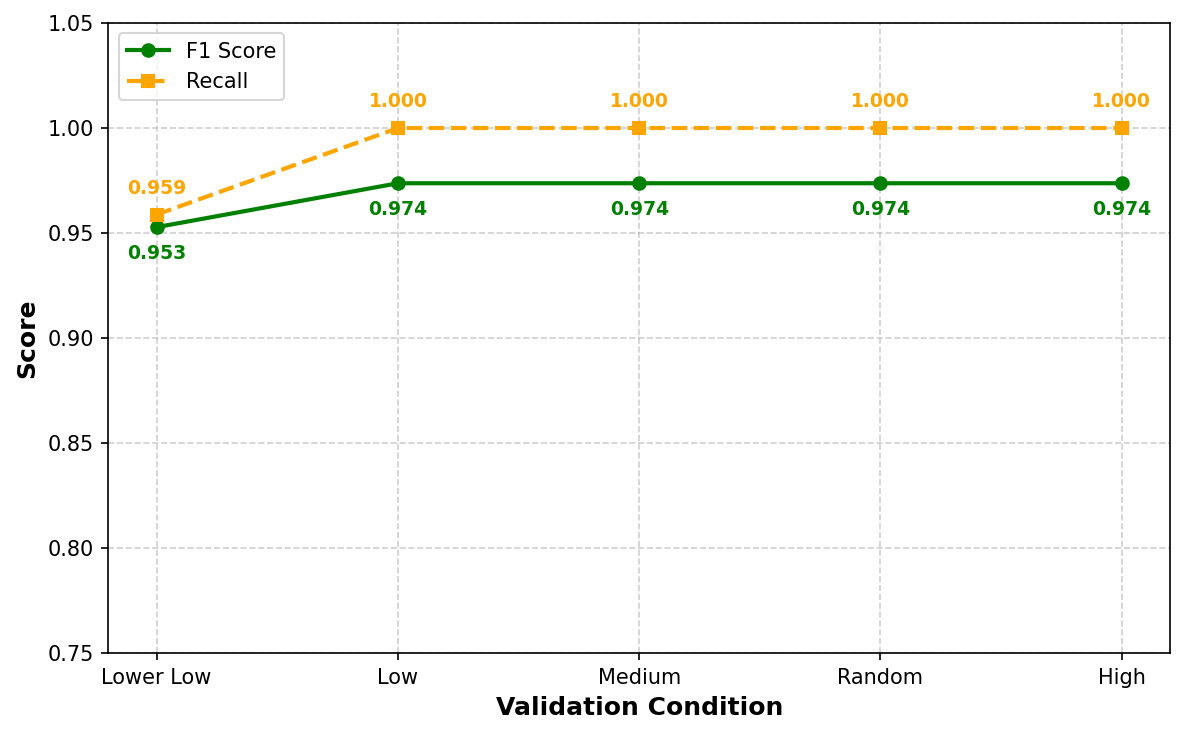

In [ ]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.9528, 0.9737, 0.9737, 0.9737, 0.9737]
recalls =   [0.9588, 1.0000, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5), dpi=150)

# Plot both F1 and Recall with custom colors
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values with better spacing
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
    plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

Other Lab

In [63]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 125.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia


Processing validation files:   0%|          | 0/4 [00:00<?, ?it/s]

Processing validation files: 100%|██████████| 4/4 [00:35<00:00,  8.99s/it]


Total validation segments loaded: 4231


Formatting segments: 100%|██████████| 4231/4231 [00:00<00:00, 6913.17it/s]


Running inference on validation data...


Inference: 100%|██████████| 133/133 [00:03<00:00, 34.66it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9754
F1 Score:  0.9681
Precision: 0.9994
Recall:    0.9388

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2548             | 1                
Actual Positive: 103              | 1579             


{'accuracy': 0.9754195225714961,
 'f1': 0.9681177191906806,
 'precision': 0.9993670886075949,
 'recall': 0.9387633769322236}

In [64]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 130.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata


Processing validation files: 100%|██████████| 4/4 [00:31<00:00,  7.78s/it]


Total validation segments loaded: 3702


Formatting segments: 100%|██████████| 3702/3702 [00:00<00:00, 7108.10it/s]


Running inference on validation data...


Inference: 100%|██████████| 116/116 [00:03<00:00, 35.31it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9903
F1 Score:  0.9882
Precision: 1.0000
Recall:    0.9766

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2161             | 0                
Actual Positive: 36               | 1505             


{'accuracy': 0.9902755267423015,
 'f1': 0.9881812212738017,
 'precision': 1.0,
 'recall': 0.9766385463984426}

In [65]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 160.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester


Processing validation files: 100%|██████████| 6/6 [00:03<00:00,  1.85it/s]


Total validation segments loaded: 2770


Formatting segments: 100%|██████████| 2770/2770 [00:00<00:00, 8514.01it/s]


Running inference on validation data...


Inference: 100%|██████████| 87/87 [00:02<00:00, 36.50it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9632
F1 Score:  0.8886
Precision: 0.7996
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2261             | 102              
Actual Positive: 0                | 407              


{'accuracy': 0.9631768953068592,
 'f1': 0.888646288209607,
 'precision': 0.7996070726915521,
 'recall': 1.0}

In [66]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil


Processing validation files:   0%|          | 0/5 [00:00<?, ?it/s]

Processing validation files: 100%|██████████| 5/5 [00:05<00:00,  1.05s/it]


Total validation segments loaded: 4289


Formatting segments: 100%|██████████| 4289/4289 [00:00<00:00, 7233.95it/s]


Running inference on validation data...


Inference: 100%|██████████| 135/135 [00:03<00:00, 35.49it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9573
F1 Score:  0.9540
Precision: 0.9120
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 183              
Actual Positive: 0                | 1896             


{'accuracy': 0.9573327115877827,
 'f1': 0.9539622641509434,
 'precision': 0.911976911976912,
 'recall': 1.0}

In [67]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen"


print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)

/home/lisa/Arupreza/UIDS-II/uids/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/TrainTesla/titans-mac-can-classifier ---
Loading Custom Titans Model...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen


Processing validation files:   0%|          | 0/3 [00:00<?, ?it/s]

Processing validation files:  33%|███▎      | 1/3 [00:02<00:05,  2.99s/it]/home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/utils.py:91: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  67%|██████▋   | 2/3 [00:06<00:03,  3.25s/it]/home/lisa/Arupreza/UIDS/UIDS-II/SFTSrc/titans/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 3/3 [00:08<00:00,  2.99s/it]


Total validation segments loaded: 5179


Formatting segments: 100%|██████████| 5179/5179 [00:00<00:00, 6903.32it/s]


Running inference on validation data...


Inference: 100%|██████████| 162/162 [00:04<00:00, 35.20it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9367
F1 Score:  0.8931
Precision: 0.8164
Recall:    0.9856

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 3481             | 308              
Actual Positive: 20               | 1370             


{'accuracy': 0.936667310291562,
 'f1': 0.8930899608865711,
 'precision': 0.8164481525625745,
 'recall': 0.9856115107913669}

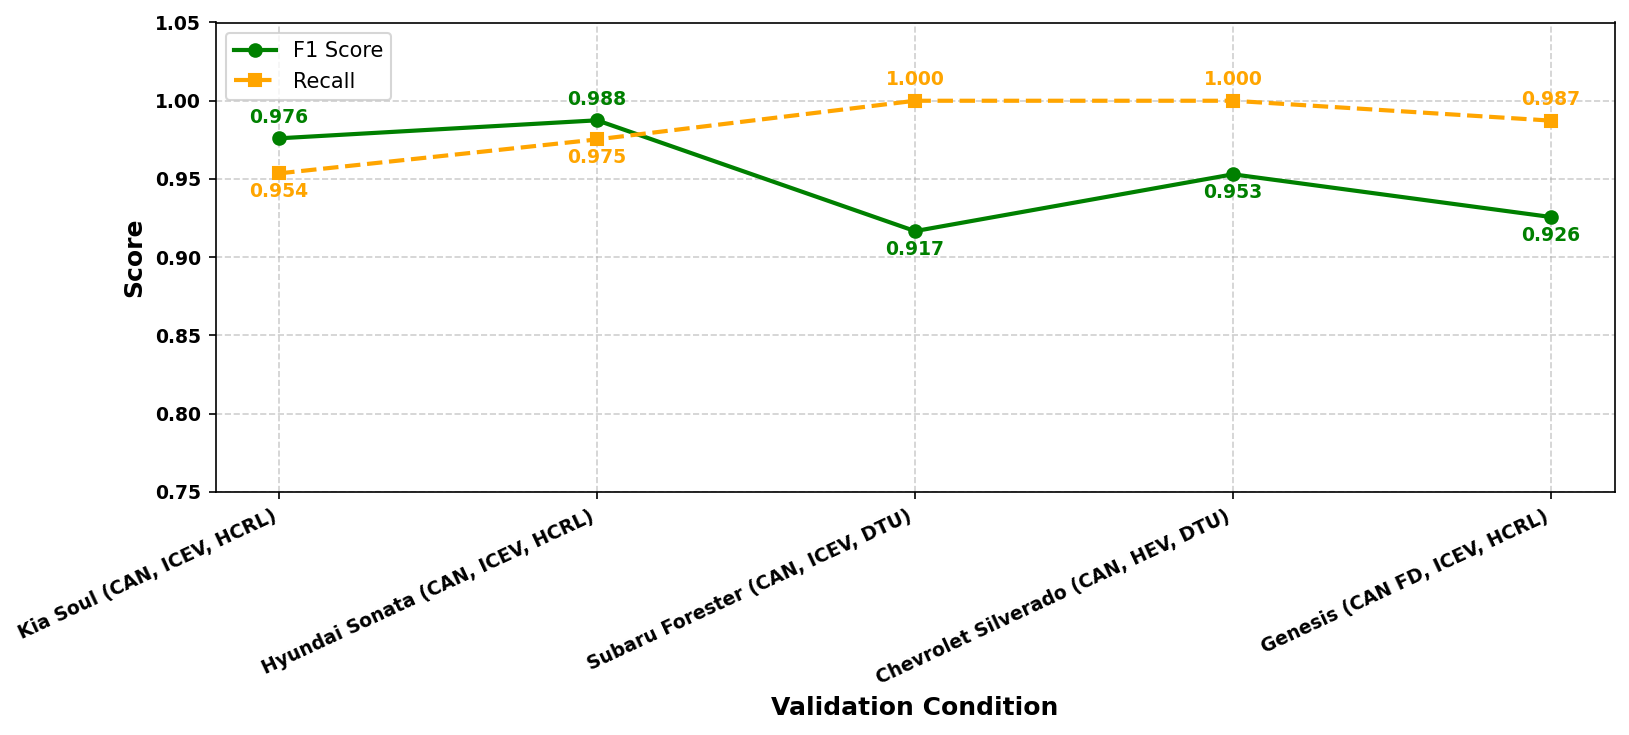

In [68]:
# Labels and values
labels = [
    'Kia Soul (CAN, ICEV, HCRL)',
    'Hyundai Sonata (CAN, ICEV, HCRL)',
    'Subaru Forester (CAN, ICEV, DTU)',
    'Chevrolet Silverado (CAN, HEV, DTU)',
    'Genesis (CAN FD, ICEV, HCRL)'
]
f1_scores = [0.9760, 0.9875, 0.9167, 0.9530, 0.9257]
recalls =   [0.9536, 0.9753, 1.0000, 1.0000, 0.9873]

# Create figure
plt.figure(figsize=(11, 5), dpi=150)

# Plot both F1 and Recall
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Dynamic annotation placement (prevents overlap)
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    # If F1 < Recall → F1 below, Recall above
    if f1 < rec:
        plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
        plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')
    else:
        # If F1 > Recall → F1 above, Recall below
        plt.text(i, f1 + 0.010, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
        plt.text(i, rec - 0.015, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.yticks(np.arange(0.75, 1.05, 0.05), fontsize=9, fontweight='bold')
plt.xticks(rotation=25, ha='right', fontsize=9, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()


Train  on Gennesis

In [130]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Lower Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Lower Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.02it/s]


Total validation segments loaded: 3311


Formatting segments: 100%|██████████| 3311/3311 [00:00<00:00, 8442.43it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 12.15it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9598
F1 Score:  0.9361
Precision: 0.9250
Recall:    0.9475

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 54               | 975              


{'accuracy': 0.959830866807611,
 'f1': 0.9361497839654345,
 'precision': 0.9250474383301708,
 'recall': 0.9475218658892128}

In [131]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.09it/s]


Total validation segments loaded: 3311


Formatting segments: 100%|██████████| 3311/3311 [00:00<00:00, 8329.50it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 12.06it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9758
F1 Score:  0.9625
Precision: 0.9286
Recall:    0.9990

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 1                | 1028             


{'accuracy': 0.9758381153729991,
 'f1': 0.9625468164794008,
 'precision': 0.928635953026197,
 'recall': 0.9990281827016521}

In [132]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Medium"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Medium


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.04it/s]


Total validation segments loaded: 3311


Formatting segments: 100%|██████████| 3311/3311 [00:00<00:00, 8267.51it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 11.99it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9761
F1 Score:  0.9630
Precision: 0.9287
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 0                | 1029             


{'accuracy': 0.9761401389308366,
 'f1': 0.9630322882545624,
 'precision': 0.9287003610108303,
 'recall': 1.0}

In [133]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Random"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Random


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.06it/s]


Total validation segments loaded: 3309


Formatting segments: 100%|██████████| 3309/3309 [00:00<00:00, 8328.32it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 11.98it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9761
F1 Score:  0.9630
Precision: 0.9286
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 0                | 1027             


{'accuracy': 0.9761257177394983,
 'f1': 0.9629629629629629,
 'precision': 0.9285714285714286,
 'recall': 1.0}

In [134]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/High"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/High


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.07it/s]


Total validation segments loaded: 3311


Formatting segments: 100%|██████████| 3311/3311 [00:00<00:00, 7837.56it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 11.93it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9761
F1 Score:  0.9630
Precision: 0.9287
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 0                | 1029             


{'accuracy': 0.9761401389308366,
 'f1': 0.9630322882545624,
 'precision': 0.9287003610108303,
 'recall': 1.0}

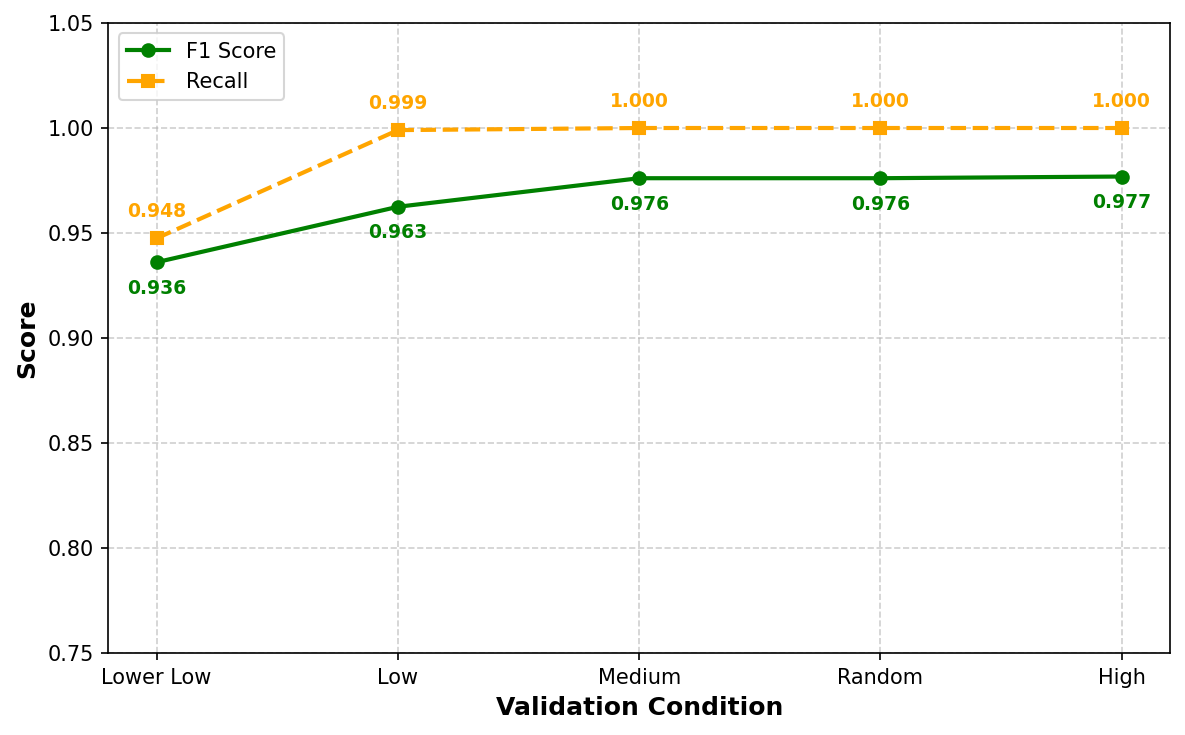

In [135]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.9361, 0.9625, 0.9761, 0.9761, 0.9769]
recalls =   [0.9475, 0.9990, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5), dpi=150)

# Plot both F1 and Recall with custom colors
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values with better spacing
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
    plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

In [136]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Lower Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Lower Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.04it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8481.87it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 12.16it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9128
F1 Score:  0.8734
Precision: 0.7942
Recall:    0.9701

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2051             | 261              
Actual Positive: 31               | 1007             


{'accuracy': 0.9128358208955224,
 'f1': 0.8733738074588031,
 'precision': 0.7941640378548895,
 'recall': 0.9701348747591522}

In [137]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.07it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8491.54it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 12.07it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9221
F1 Score:  0.8885
Precision: 0.8000
Recall:    0.9990

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2049             | 260              
Actual Positive: 1                | 1040             


{'accuracy': 0.922089552238806,
 'f1': 0.888509184109355,
 'precision': 0.8,
 'recall': 0.9990393852065321}

In [138]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Medium"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Medium


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.05it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8133.48it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 12.01it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9224
F1 Score:  0.8890
Precision: 0.8002
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2049             | 260              
Actual Positive: 0                | 1041             


{'accuracy': 0.9223880597014925,
 'f1': 0.8889837745516652,
 'precision': 0.8001537279016141,
 'recall': 1.0}

In [139]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Random"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Random


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.08it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8282.99it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 12.00it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9224
F1 Score:  0.8890
Precision: 0.8002
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2049             | 260              
Actual Positive: 0                | 1041             


{'accuracy': 0.9223880597014925,
 'f1': 0.8889837745516652,
 'precision': 0.8001537279016141,
 'recall': 1.0}

In [140]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/High"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/High


Processing validation files: 100%|██████████| 4/4 [00:04<00:00,  1.00s/it]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 7969.84it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 11.96it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9224
F1 Score:  0.8890
Precision: 0.8002
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2049             | 260              
Actual Positive: 0                | 1041             


{'accuracy': 0.9223880597014925,
 'f1': 0.8889837745516652,
 'precision': 0.8001537279016141,
 'recall': 1.0}

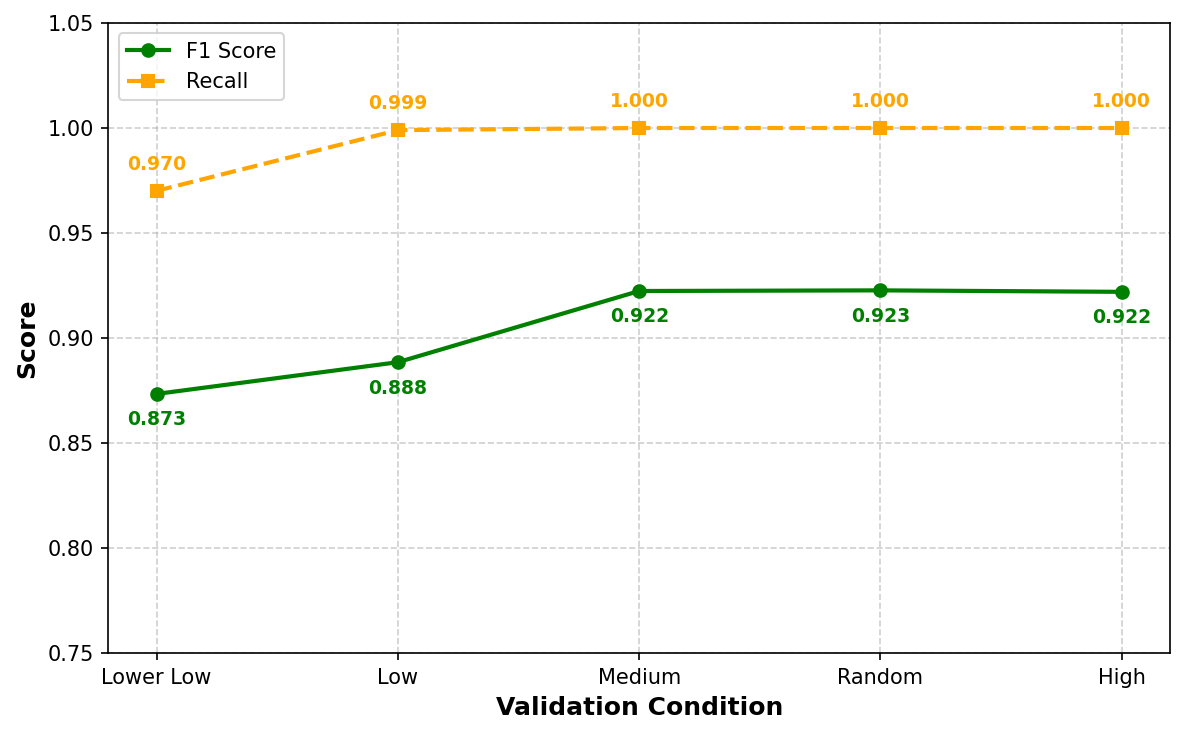

In [141]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.8734, 0.8885, 0.9224, 0.9227, 0.9220]
recalls =   [0.9701, 0.9990, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5), dpi=150)

# Plot both F1 and Recall with custom colors
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values with better spacing
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
    plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

In [142]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Lower Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Lower Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.02it/s]


Total validation segments loaded: 3385


Formatting segments: 100%|██████████| 3385/3385 [00:00<00:00, 8791.72it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 12.17it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9516
F1 Score:  0.9249
Precision: 0.8907
Recall:    0.9619

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2211             | 124              
Actual Positive: 40               | 1010             


{'accuracy': 0.9515509601181684,
 'f1': 0.924908424908425,
 'precision': 0.890652557319224,
 'recall': 0.9619047619047619}

In [143]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.07it/s]


Total validation segments loaded: 3387


Formatting segments: 100%|██████████| 3387/3387 [00:00<00:00, 8573.77it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 12.05it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9631
F1 Score:  0.9439
Precision: 0.8945
Recall:    0.9990

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2211             | 124              
Actual Positive: 1                | 1051             


{'accuracy': 0.9630941836433422,
 'f1': 0.9438706780422093,
 'precision': 0.894468085106383,
 'recall': 0.9990494296577946}

In [144]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Medium"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Medium


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.07it/s]


Total validation segments loaded: 3386


Formatting segments: 100%|██████████| 3386/3386 [00:00<00:00, 8240.68it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 12.01it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9634
F1 Score:  0.9443
Precision: 0.8946
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 124              
Actual Positive: 0                | 1052             


{'accuracy': 0.9633786178381571,
 'f1': 0.9443447037701975,
 'precision': 0.8945578231292517,
 'recall': 1.0}

In [145]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Random"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Random


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.01it/s]


Total validation segments loaded: 3386


Formatting segments: 100%|██████████| 3386/3386 [00:00<00:00, 8500.28it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 11.98it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9634
F1 Score:  0.9443
Precision: 0.8946
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 124              
Actual Positive: 0                | 1052             


{'accuracy': 0.9633786178381571,
 'f1': 0.9443447037701975,
 'precision': 0.8945578231292517,
 'recall': 1.0}

In [146]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/High"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/High


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.03it/s]


Total validation segments loaded: 3387


Formatting segments: 100%|██████████| 3387/3387 [00:00<00:00, 8066.15it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 11.95it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9634
F1 Score:  0.9443
Precision: 0.8946
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2211             | 124              
Actual Positive: 0                | 1052             


{'accuracy': 0.9633894301741954,
 'f1': 0.9443447037701975,
 'precision': 0.8945578231292517,
 'recall': 1.0}

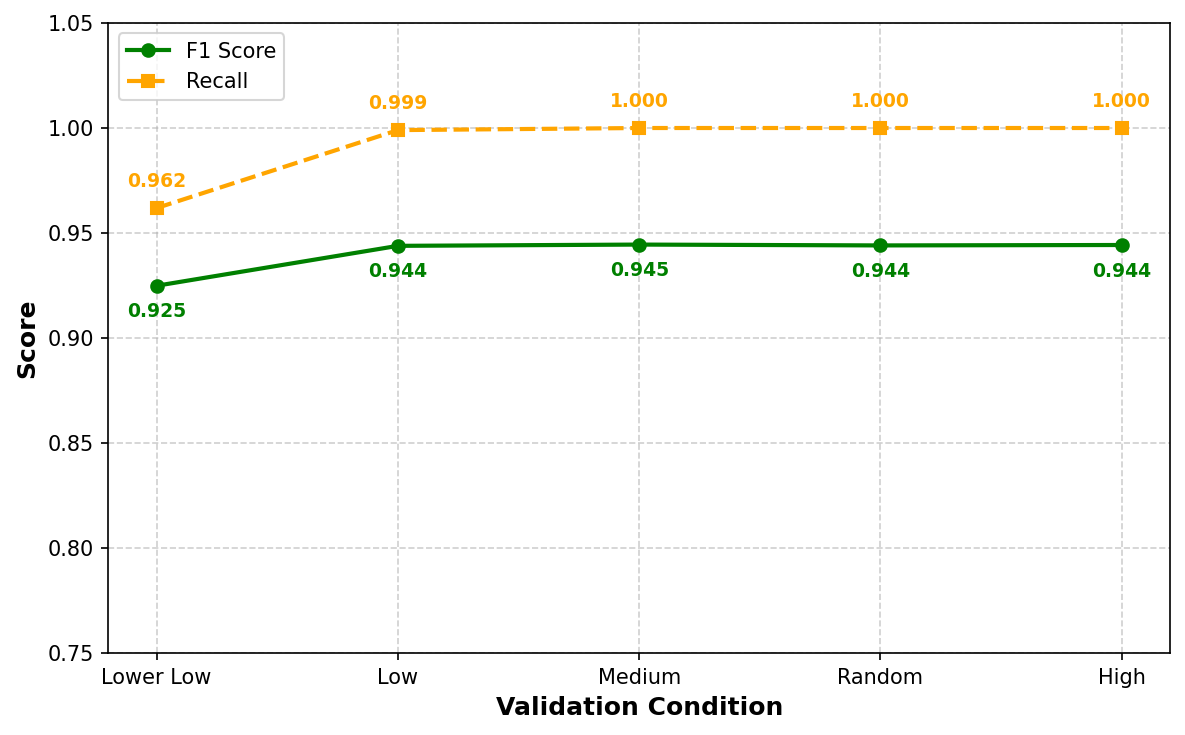

In [147]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.9249, 0.9439, 0.9445, 0.9441, 0.9443]
recalls =   [0.9619, 0.9990, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5), dpi=150)

# Plot both F1 and Recall with custom colors
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values with better spacing
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
    plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

In [20]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 160.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester


Processing validation files: 100%|██████████| 6/6 [00:03<00:00,  1.86it/s]


Total validation segments loaded: 2770


Formatting segments: 100%|██████████| 2770/2770 [00:00<00:00, 9082.00it/s]


Running inference on validation data...


Inference: 100%|██████████| 174/174 [00:14<00:00, 12.03it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9635
F1 Score:  0.8896
Precision: 0.8012
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2262             | 101              
Actual Positive: 0                | 407              


{'accuracy': 0.9635379061371842,
 'f1': 0.8896174863387978,
 'precision': 0.8011811023622047,
 'recall': 1.0}

In [21]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen


Processing validation files:   0%|          | 0/4 [00:00<?, ?it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  50%|█████     | 2/4 [00:06<00:06,  3.04s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  75%|███████▌  | 3/4 [00:09<00:03,  3.26s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:12<00:00,  3.04s/it]


Total validation segments loaded: 7232


Formatting segments: 100%|██████████| 7232/7232 [00:00<00:00, 7281.61it/s]


Running inference on validation data...


Inference: 100%|██████████| 452/452 [00:38<00:00, 11.83it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9527
F1 Score:  0.9336
Precision: 0.8854
Recall:    0.9873

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 4487             | 311              
Actual Positive: 31               | 2403             


{'accuracy': 0.9527101769911505,
 'f1': 0.9335664335664335,
 'precision': 0.8854089904200442,
 'recall': 0.9872637633525062}

In [25]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 125.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia


Processing validation files: 100%|██████████| 4/4 [00:38<00:00,  9.65s/it]


Total validation segments loaded: 4231


Formatting segments: 100%|██████████| 4231/4231 [00:00<00:00, 7047.05it/s]


Running inference on validation data...


Inference: 100%|██████████| 265/265 [00:45<00:00,  5.85it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9752
F1 Score:  0.9678
Precision: 0.9994
Recall:    0.9382

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2548             | 1                
Actual Positive: 104              | 1578             


{'accuracy': 0.9751831718269912,
 'f1': 0.9678012879484821,
 'precision': 0.999366687777074,
 'recall': 0.9381688466111772}

In [23]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil


Processing validation files: 100%|██████████| 5/5 [00:04<00:00,  1.01it/s]


Total validation segments loaded: 4289


Formatting segments: 100%|██████████| 4289/4289 [00:00<00:00, 7685.14it/s]


Running inference on validation data...


Inference: 100%|██████████| 269/269 [00:22<00:00, 11.90it/s]



Calculating metrics...

=== Validation Results ===
Accuracy:  0.9573
F1 Score:  0.9540
Precision: 0.9120
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 183              
Actual Positive: 0                | 1896             


{'accuracy': 0.9573327115877827,
 'f1': 0.9539622641509434,
 'precision': 0.911976911976912,
 'recall': 1.0}

In [24]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 130.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainGen/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata


Processing validation files: 100%|██████████| 4/4 [00:28<00:00,  7.18s/it]


Total validation segments loaded: 3702


Formatting segments: 100%|██████████| 3702/3702 [00:00<00:00, 7325.40it/s]


Running inference on validation data...


Inference: 100%|██████████| 232/232 [00:19<00:00, 11.96it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9900
F1 Score:  0.9878
Precision: 1.0000
Recall:    0.9760

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2161             | 0                
Actual Positive: 37               | 1504             


{'accuracy': 0.9900054024851431,
 'f1': 0.9878489326765189,
 'precision': 1.0,
 'recall': 0.9759896171317326}

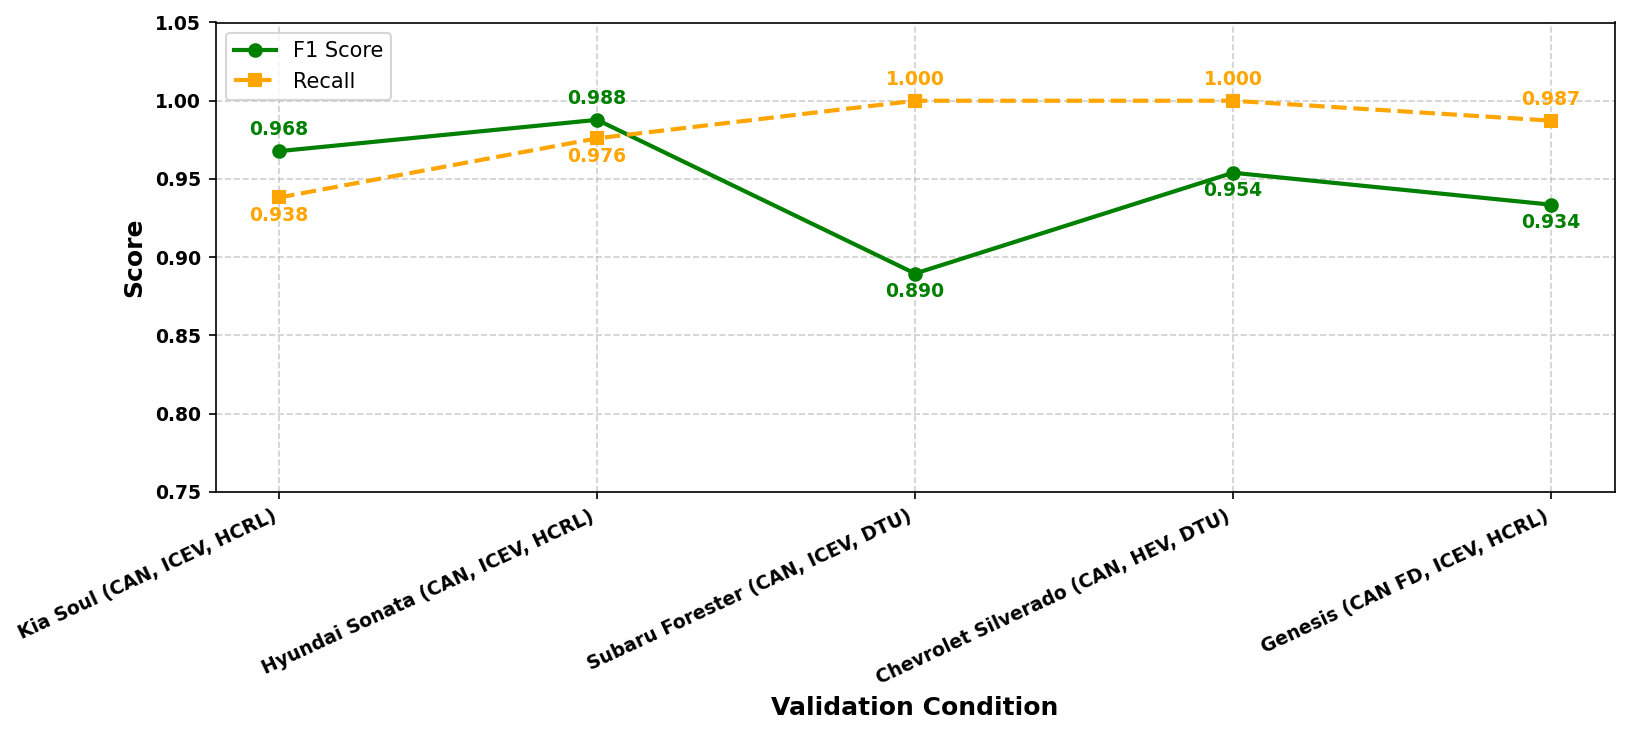

In [148]:
# Labels and values
labels = [
    'Kia Soul (CAN, ICEV, HCRL)',
    'Hyundai Sonata (CAN, ICEV, HCRL)',
    'Subaru Forester (CAN, ICEV, DTU)',
    'Chevrolet Silverado (CAN, HEV, DTU)',
    'Genesis (CAN FD, ICEV, HCRL)'
]
f1_scores = [0.9678, 0.9878, 0.8896, 0.9540, 0.9336]
recalls =   [0.9382, 0.9760, 1.0000, 1.0000, 0.9873]

# Create figure
plt.figure(figsize=(11, 5), dpi=150)

# Plot both F1 and Recall
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Dynamic annotation placement (prevents overlap)
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    # If F1 < Recall → F1 below, Recall above
    if f1 < rec:
        plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
        plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')
    else:
        # If F1 > Recall → F1 above, Recall below
        plt.text(i, f1 + 0.010, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
        plt.text(i, rec - 0.015, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.yticks(np.arange(0.75, 1.05, 0.05), fontsize=9, fontweight='bold')
plt.xticks(rotation=25, ha='right', fontsize=9, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()


Train on Tesla

In [149]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Lower Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Lower Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.08it/s]


Total validation segments loaded: 3311


Formatting segments: 100%|██████████| 3311/3311 [00:00<00:00, 8394.21it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 12.15it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9598
F1 Score:  0.9361
Precision: 0.9250
Recall:    0.9475

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 54               | 975              


{'accuracy': 0.959830866807611,
 'f1': 0.9361497839654345,
 'precision': 0.9250474383301708,
 'recall': 0.9475218658892128}

In [150]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.09it/s]


Total validation segments loaded: 3311


Formatting segments: 100%|██████████| 3311/3311 [00:00<00:00, 8271.94it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 12.06it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9758
F1 Score:  0.9625
Precision: 0.9286
Recall:    0.9990

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 1                | 1028             


{'accuracy': 0.9758381153729991,
 'f1': 0.9625468164794008,
 'precision': 0.928635953026197,
 'recall': 0.9990281827016521}

In [151]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Medium"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Medium


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.06it/s]


Total validation segments loaded: 3311


Formatting segments: 100%|██████████| 3311/3311 [00:00<00:00, 8210.96it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 11.99it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9761
F1 Score:  0.9630
Precision: 0.9287
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 0                | 1029             


{'accuracy': 0.9761401389308366,
 'f1': 0.9630322882545624,
 'precision': 0.9287003610108303,
 'recall': 1.0}

In [152]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Random"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Random


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.04it/s]


Total validation segments loaded: 3309


Formatting segments: 100%|██████████| 3309/3309 [00:00<00:00, 8125.16it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 11.97it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9761
F1 Score:  0.9630
Precision: 0.9286
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 0                | 1027             


{'accuracy': 0.9761257177394983,
 'f1': 0.9629629629629629,
 'precision': 0.9285714285714286,
 'recall': 1.0}

In [153]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/High"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/High


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.01it/s]


Total validation segments loaded: 3311


Formatting segments: 100%|██████████| 3311/3311 [00:00<00:00, 7766.31it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 11.94it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9761
F1 Score:  0.9630
Precision: 0.9287
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 0                | 1029             


{'accuracy': 0.9761401389308366,
 'f1': 0.9630322882545624,
 'precision': 0.9287003610108303,
 'recall': 1.0}

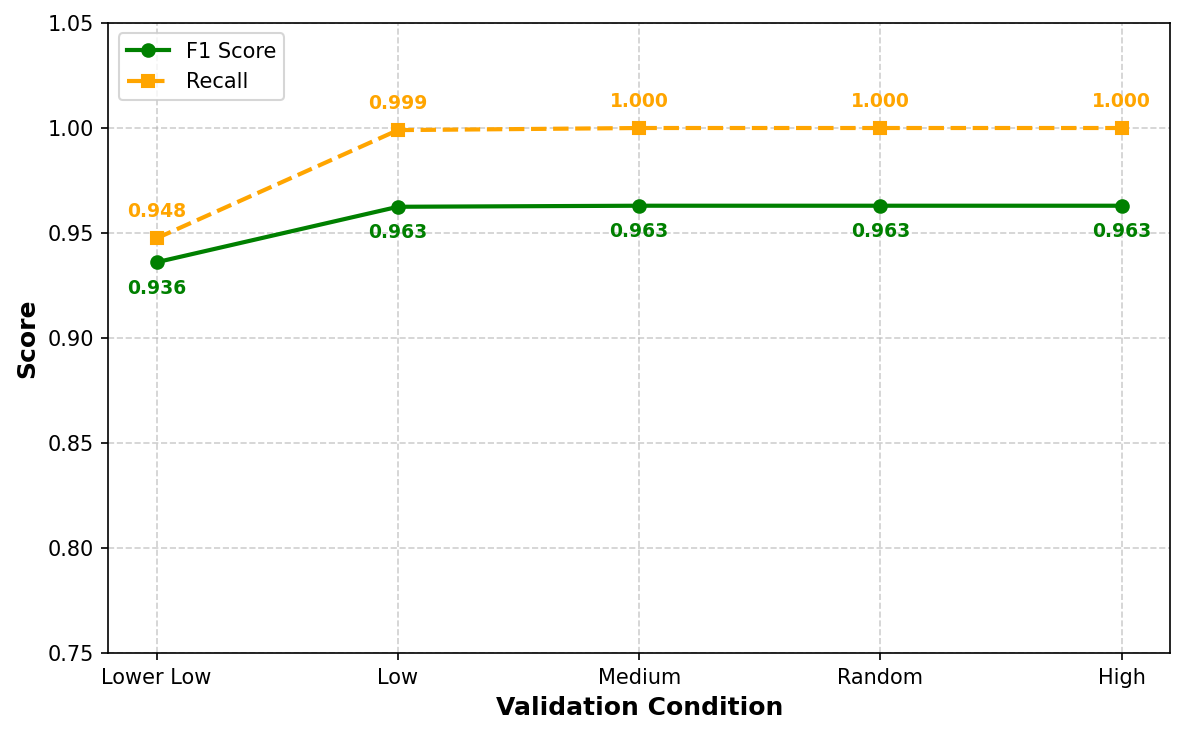

In [154]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.9361, 0.9625, 0.9630, 0.9630, 0.9630]
recalls =   [0.9475, 0.9990, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5), dpi=150)

# Plot both F1 and Recall with custom colors
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values with better spacing
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
    plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

In [155]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Lower Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Lower Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.04it/s]


Total validation segments loaded: 3385


Formatting segments: 100%|██████████| 3385/3385 [00:00<00:00, 8537.42it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 12.14it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9513
F1 Score:  0.9244
Precision: 0.8906
Recall:    0.9610

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2211             | 124              
Actual Positive: 41               | 1009             


{'accuracy': 0.9512555391432792,
 'f1': 0.9244159413650939,
 'precision': 0.8905560458958517,
 'recall': 0.960952380952381}

In [156]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.09it/s]


Total validation segments loaded: 3387


Formatting segments: 100%|██████████| 3387/3387 [00:00<00:00, 8533.68it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 12.04it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9631
F1 Score:  0.9439
Precision: 0.8945
Recall:    0.9990

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2211             | 124              
Actual Positive: 1                | 1051             


{'accuracy': 0.9630941836433422,
 'f1': 0.9438706780422093,
 'precision': 0.894468085106383,
 'recall': 0.9990494296577946}

In [157]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Medium"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Medium


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.02it/s]


Total validation segments loaded: 3386


Formatting segments: 100%|██████████| 3386/3386 [00:00<00:00, 8225.43it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 11.98it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9634
F1 Score:  0.9443
Precision: 0.8946
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 124              
Actual Positive: 0                | 1052             


{'accuracy': 0.9633786178381571,
 'f1': 0.9443447037701975,
 'precision': 0.8945578231292517,
 'recall': 1.0}

In [158]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Random"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/Random


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.02it/s]


Total validation segments loaded: 3386


Formatting segments: 100%|██████████| 3386/3386 [00:00<00:00, 8285.46it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 11.97it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9634
F1 Score:  0.9443
Precision: 0.8946
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 124              
Actual Positive: 0                | 1052             


{'accuracy': 0.9633786178381571,
 'f1': 0.9443447037701975,
 'precision': 0.8945578231292517,
 'recall': 1.0}

In [159]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/High"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Sil/High


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.03it/s]


Total validation segments loaded: 3387


Formatting segments: 100%|██████████| 3387/3387 [00:00<00:00, 8001.58it/s]


Running inference on validation data...


Inference: 100%|██████████| 212/212 [00:17<00:00, 11.93it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9634
F1 Score:  0.9443
Precision: 0.8946
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2211             | 124              
Actual Positive: 0                | 1052             


{'accuracy': 0.9633894301741954,
 'f1': 0.9443447037701975,
 'precision': 0.8945578231292517,
 'recall': 1.0}

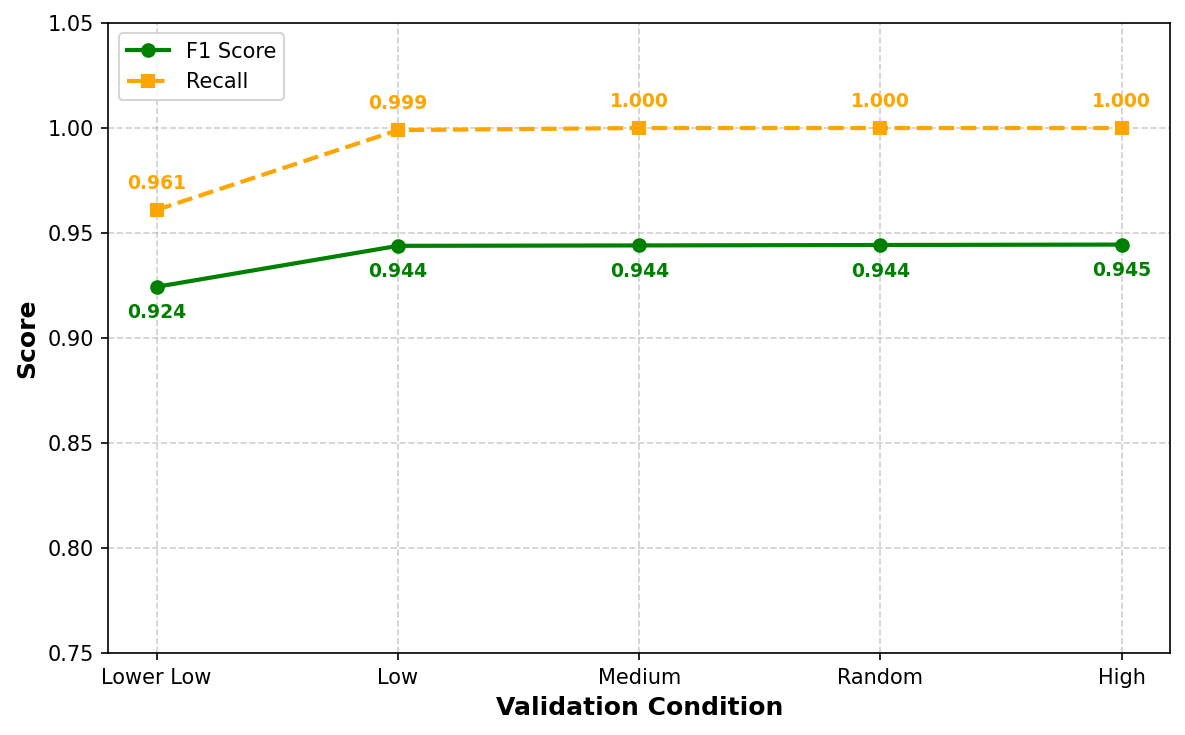

In [160]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.9244, 0.9439, 0.9441, 0.9443, 0.9445]
recalls =   [0.9610, 0.9990, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5), dpi=150)

# Plot both F1 and Recall with custom colors
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values with better spacing
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
    plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

In [161]:
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Lower Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Lower Low


Processing validation files:  25%|██▌       | 1/4 [00:00<00:01,  1.69it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  50%|█████     | 2/4 [00:01<00:01,  1.76it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.28s/it]


Total validation segments loaded: 3287


Formatting segments: 100%|██████████| 3287/3287 [00:00<00:00, 8291.59it/s]


Running inference on validation data...


Inference: 100%|██████████| 206/206 [00:16<00:00, 12.13it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9909
F1 Score:  0.9851
Precision: 0.9970
Recall:    0.9735

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 3                
Actual Positive: 27               | 993              


{'accuracy': 0.9908731365987222,
 'f1': 0.9851190476190477,
 'precision': 0.9969879518072289,
 'recall': 0.9735294117647059}

In [162]:
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Low


Processing validation files:  50%|█████     | 2/4 [00:01<00:01,  1.71it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.34s/it]


Total validation segments loaded: 3287


Formatting segments: 100%|██████████| 3287/3287 [00:00<00:00, 8229.52it/s]


Running inference on validation data...


Inference: 100%|██████████| 206/206 [00:17<00:00, 12.04it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9991
F1 Score:  0.9985
Precision: 0.9971
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 3                
Actual Positive: 0                | 1020             


{'accuracy': 0.9990873136598722,
 'f1': 0.9985315712187959,
 'precision': 0.9970674486803519,
 'recall': 1.0}

In [163]:
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Medium"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Medium


Processing validation files:  75%|███████▌  | 3/4 [00:01<00:00,  1.52it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.37s/it]


Total validation segments loaded: 3287


Formatting segments: 100%|██████████| 3287/3287 [00:00<00:00, 8007.45it/s]


Running inference on validation data...


Inference: 100%|██████████| 206/206 [00:17<00:00, 11.99it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9991
F1 Score:  0.9985
Precision: 0.9971
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 3                
Actual Positive: 0                | 1020             


{'accuracy': 0.9990873136598722,
 'f1': 0.9985315712187959,
 'precision': 0.9970674486803519,
 'recall': 1.0}

In [164]:
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Random"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Random


Processing validation files:  50%|█████     | 2/4 [00:01<00:01,  1.63it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.33s/it]


Total validation segments loaded: 3288


Formatting segments: 100%|██████████| 3288/3288 [00:00<00:00, 8292.31it/s]


Running inference on validation data...


Inference: 100%|██████████| 206/206 [00:17<00:00, 11.98it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9991
F1 Score:  0.9985
Precision: 0.9971
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2265             | 3                
Actual Positive: 0                | 1020             


{'accuracy': 0.9990875912408759,
 'f1': 0.9985315712187959,
 'precision': 0.9970674486803519,
 'recall': 1.0}

In [165]:
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/High"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/High


Processing validation files:  50%|█████     | 2/4 [00:01<00:01,  1.40it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.42s/it]


Total validation segments loaded: 3287


Formatting segments: 100%|██████████| 3287/3287 [00:00<00:00, 7745.40it/s]


Running inference on validation data...


Inference: 100%|██████████| 206/206 [00:17<00:00, 11.94it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9991
F1 Score:  0.9985
Precision: 0.9971
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 3                
Actual Positive: 0                | 1020             


{'accuracy': 0.9990873136598722,
 'f1': 0.9985315712187959,
 'precision': 0.9970674486803519,
 'recall': 1.0}

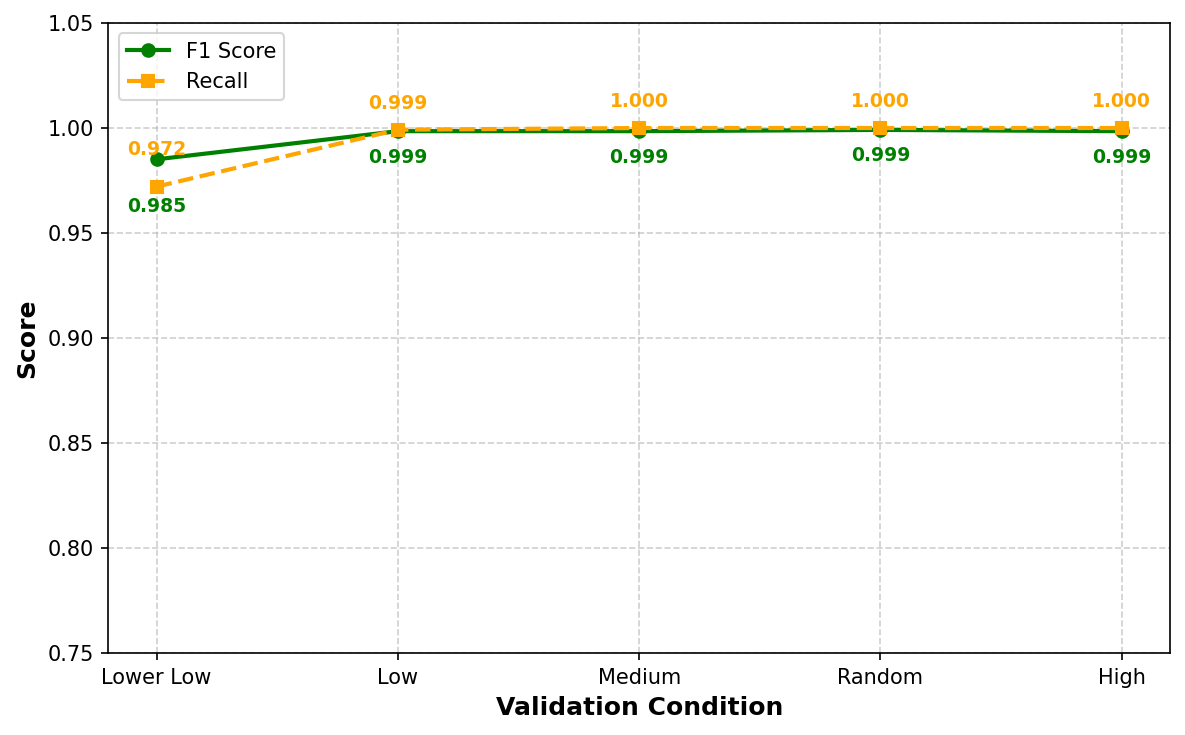

In [166]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.9851, 0.9985, 0.9985, 0.9991, 0.9985]
recalls =   [0.9721, 0.9992, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5), dpi=150)

# Plot both F1 and Recall
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values with adaptive offsets
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    if i == 0:
        # For first point, larger offset to prevent overlap
        plt.text(i, f1 - 0.025, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
        plt.text(i, rec + 0.015, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')
    else:
        # Standard offsets for others
        plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
        plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

In [167]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 160.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester


Processing validation files: 100%|██████████| 6/6 [00:03<00:00,  1.87it/s]


Total validation segments loaded: 2770


Formatting segments: 100%|██████████| 2770/2770 [00:00<00:00, 8298.27it/s]


Running inference on validation data...


Inference: 100%|██████████| 174/174 [00:14<00:00, 12.15it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9635
F1 Score:  0.8896
Precision: 0.8012
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2262             | 101              
Actual Positive: 0                | 407              


{'accuracy': 0.9635379061371842,
 'f1': 0.8896174863387978,
 'precision': 0.8011811023622047,
 'recall': 1.0}

In [168]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen


Processing validation files:  33%|███▎      | 1/3 [00:03<00:06,  3.02s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  67%|██████▋   | 2/3 [00:06<00:03,  3.26s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 3/3 [00:09<00:00,  3.01s/it]


Total validation segments loaded: 5179


Formatting segments: 100%|██████████| 5179/5179 [00:00<00:00, 6866.80it/s]


Running inference on validation data...


Inference: 100%|██████████| 324/324 [00:27<00:00, 11.92it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9369
F1 Score:  0.8934
Precision: 0.8169
Recall:    0.9856

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 3482             | 307              
Actual Positive: 20               | 1370             


{'accuracy': 0.9368603977601854,
 'f1': 0.8933811542223671,
 'precision': 0.8169350029815146,
 'recall': 0.9856115107913669}

In [169]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 125.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia


Processing validation files: 100%|██████████| 4/4 [00:36<00:00,  9.20s/it]


Total validation segments loaded: 4231


Formatting segments: 100%|██████████| 4231/4231 [00:00<00:00, 6763.94it/s]


Running inference on validation data...


Inference: 100%|██████████| 265/265 [00:22<00:00, 11.95it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9747
F1 Score:  0.9672
Precision: 0.9994
Recall:    0.9370

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2548             | 1                
Actual Positive: 106              | 1576             


{'accuracy': 0.9747104703379815,
 'f1': 0.9671678428965941,
 'precision': 0.9993658845909955,
 'recall': 0.9369797859690844}

In [170]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil


Processing validation files: 100%|██████████| 5/5 [00:05<00:00,  1.01s/it]


Total validation segments loaded: 4289


Formatting segments: 100%|██████████| 4289/4289 [00:00<00:00, 7183.19it/s]


Running inference on validation data...


Inference: 100%|██████████| 269/269 [00:22<00:00, 11.94it/s]



Calculating metrics...

=== Validation Results ===
Accuracy:  0.9573
F1 Score:  0.9540
Precision: 0.9120
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2210             | 183              
Actual Positive: 0                | 1896             


{'accuracy': 0.9573327115877827,
 'f1': 0.9539622641509434,
 'precision': 0.911976911976912,
 'recall': 1.0}

In [171]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 130.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainTesla/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata


Processing validation files: 100%|██████████| 4/4 [00:29<00:00,  7.30s/it]


Total validation segments loaded: 3702


Formatting segments: 100%|██████████| 3702/3702 [00:00<00:00, 6935.95it/s]


Running inference on validation data...


Inference: 100%|██████████| 232/232 [00:19<00:00, 11.97it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9897
F1 Score:  0.9875
Precision: 1.0000
Recall:    0.9753

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2161             | 0                
Actual Positive: 38               | 1503             


{'accuracy': 0.9897352782279849,
 'f1': 0.9875164257555847,
 'precision': 1.0,
 'recall': 0.9753406878650227}

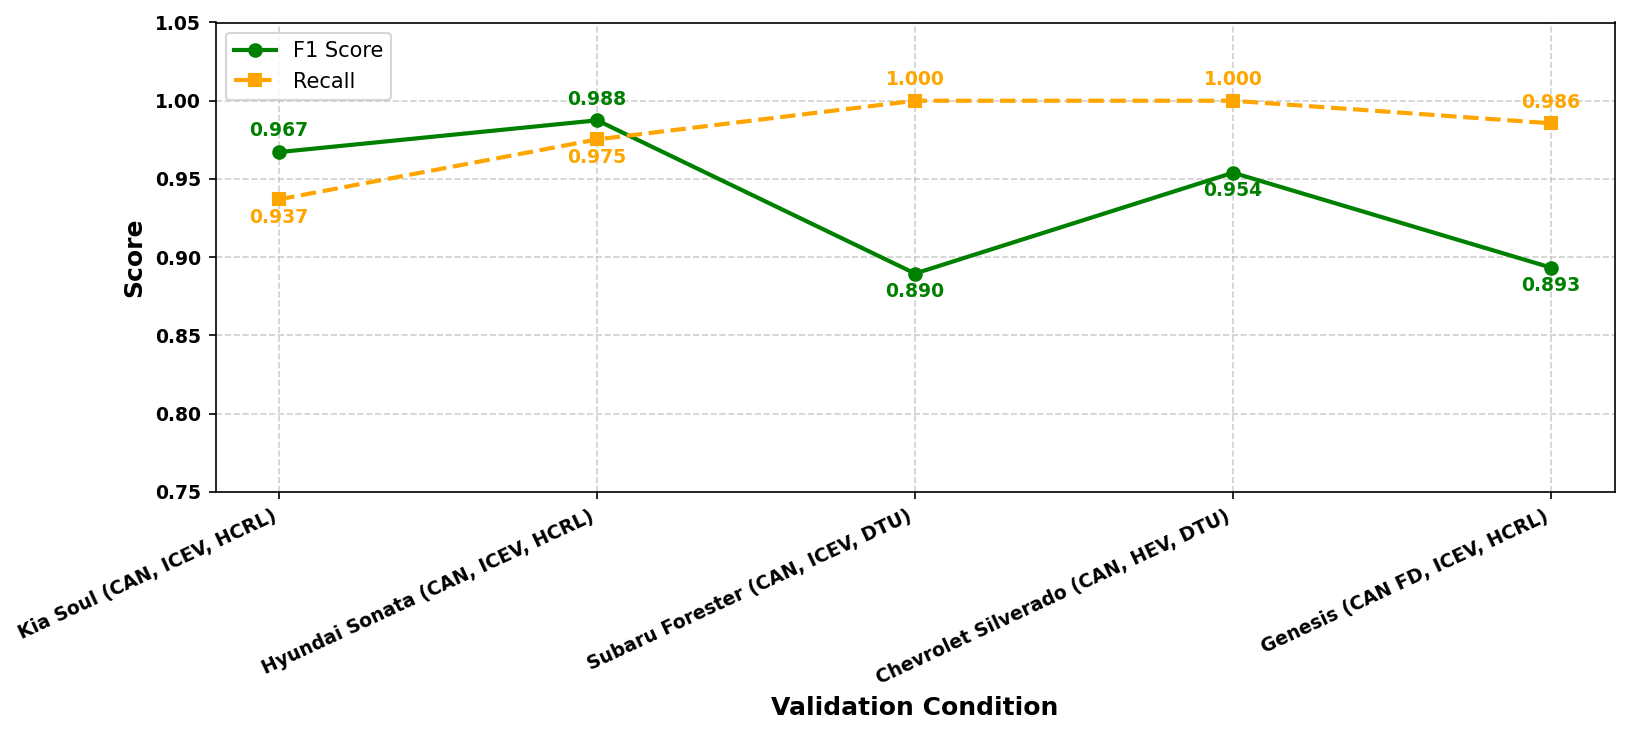

In [172]:
# Labels and values
labels = [
    'Kia Soul (CAN, ICEV, HCRL)',
    'Hyundai Sonata (CAN, ICEV, HCRL)',
    'Subaru Forester (CAN, ICEV, DTU)',
    'Chevrolet Silverado (CAN, HEV, DTU)',
    'Genesis (CAN FD, ICEV, HCRL)'
]
f1_scores = [0.9672, 0.9875, 0.8896, 0.9540, 0.8934]
recalls =   [0.9370, 0.9753, 1.0000, 1.0000, 0.9856]

# Create figure
plt.figure(figsize=(11, 5), dpi=150)

# Plot both F1 and Recall
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Dynamic annotation placement (prevents overlap)
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    # If F1 < Recall → F1 below, Recall above
    if f1 < rec:
        plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
        plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')
    else:
        # If F1 > Recall → F1 above, Recall below
        plt.text(i, f1 + 0.010, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
        plt.text(i, rec - 0.015, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.yticks(np.arange(0.75, 1.05, 0.05), fontsize=9, fontweight='bold')
plt.xticks(rotation=25, ha='right', fontsize=9, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()


Tran on Silverado

In [19]:
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Lower Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Lower Low


Processing validation files:  25%|██▌       | 1/4 [00:00<00:01,  1.65it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  50%|█████     | 2/4 [00:01<00:01,  1.73it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.30s/it]


Total validation segments loaded: 3287


Formatting segments: 100%|██████████| 3287/3287 [00:00<00:00, 8462.64it/s]


Running inference on validation data...


Inference: 100%|██████████| 206/206 [00:17<00:00, 12.03it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9909
F1 Score:  0.9851
Precision: 0.9970
Recall:    0.9735

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 3                
Actual Positive: 27               | 993              


{'accuracy': 0.9908731365987222,
 'f1': 0.9851190476190477,
 'precision': 0.9969879518072289,
 'recall': 0.9735294117647059}

In [20]:
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Low


Processing validation files:  50%|█████     | 2/4 [00:01<00:01,  1.71it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.37s/it]


Total validation segments loaded: 3287


Formatting segments: 100%|██████████| 3287/3287 [00:00<00:00, 8354.15it/s]


Running inference on validation data...


Inference: 100%|██████████| 206/206 [00:17<00:00, 11.99it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9991
F1 Score:  0.9985
Precision: 0.9971
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 3                
Actual Positive: 0                | 1020             


{'accuracy': 0.9990873136598722,
 'f1': 0.9985315712187959,
 'precision': 0.9970674486803519,
 'recall': 1.0}

In [21]:
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Medium"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Medium


Processing validation files:  75%|███████▌  | 3/4 [00:02<00:00,  1.50it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.39s/it]


Total validation segments loaded: 3287


Formatting segments: 100%|██████████| 3287/3287 [00:00<00:00, 8109.95it/s]


Running inference on validation data...


Inference: 100%|██████████| 206/206 [00:17<00:00, 11.96it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9991
F1 Score:  0.9985
Precision: 0.9971
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 3                
Actual Positive: 0                | 1020             


{'accuracy': 0.9990873136598722,
 'f1': 0.9985315712187959,
 'precision': 0.9970674486803519,
 'recall': 1.0}

In [22]:
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Random"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/Random


Processing validation files:  50%|█████     | 2/4 [00:01<00:01,  1.67it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.28s/it]


Total validation segments loaded: 3288


Formatting segments: 100%|██████████| 3288/3288 [00:00<00:00, 8044.76it/s]


Running inference on validation data...


Inference: 100%|██████████| 206/206 [00:17<00:00, 11.93it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9988
F1 Score:  0.9980
Precision: 0.9961
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 4                
Actual Positive: 0                | 1020             


{'accuracy': 0.9987834549878345,
 'f1': 0.9980430528375733,
 'precision': 0.99609375,
 'recall': 1.0}

In [23]:
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/High"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Gen/High


Processing validation files:  50%|█████     | 2/4 [00:01<00:01,  1.40it/s]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 4/4 [00:05<00:00,  1.45s/it]


Total validation segments loaded: 3287


Formatting segments: 100%|██████████| 3287/3287 [00:00<00:00, 8017.16it/s]


Running inference on validation data...


Inference: 100%|██████████| 206/206 [00:17<00:00, 11.83it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9991
F1 Score:  0.9985
Precision: 0.9971
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2264             | 3                
Actual Positive: 0                | 1020             


{'accuracy': 0.9990873136598722,
 'f1': 0.9985315712187959,
 'precision': 0.9970674486803519,
 'recall': 1.0}

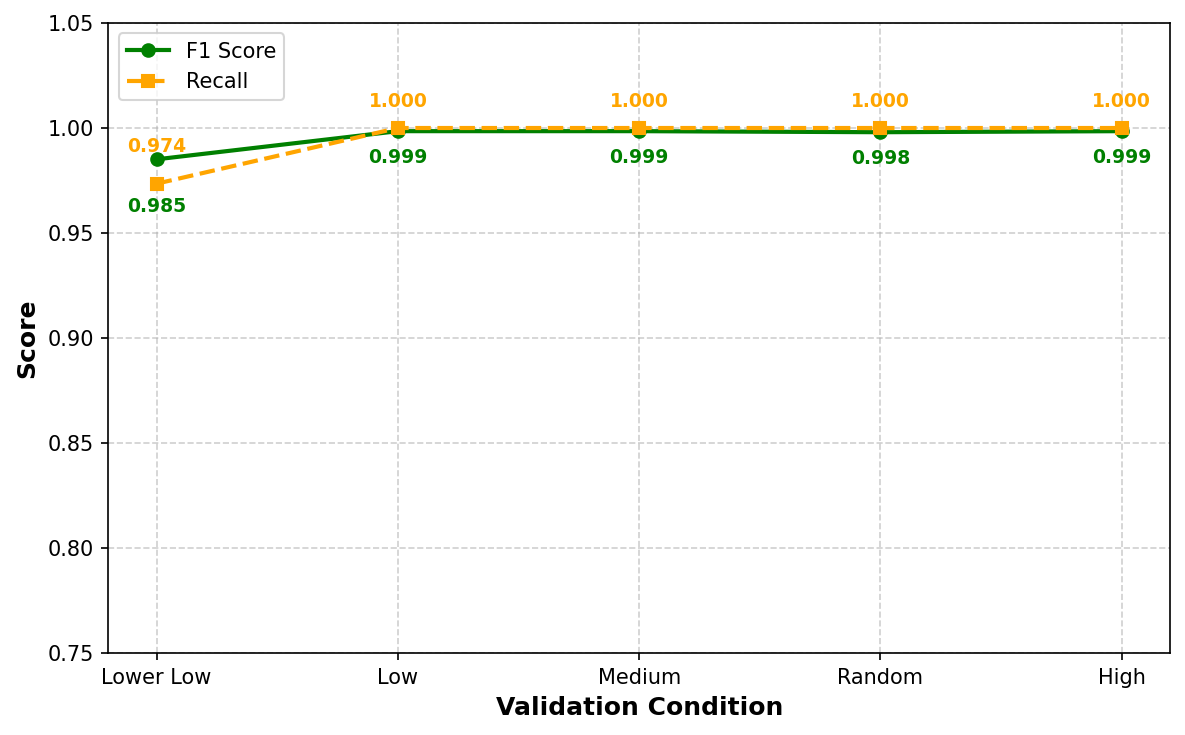

In [25]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.9851, 0.9985, 0.9985, 0.9980, 0.9985]
recalls   = [0.9735, 1.0000, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5), dpi=150)

# Plot both F1 and Recall
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values with adaptive offsets
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    if i == 0:
        # For first point, larger offset to prevent overlap
        plt.text(i, f1 - 0.025, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
        plt.text(i, rec + 0.015, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')
    else:
        # Standard offsets for others
        plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
        plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()

In [26]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Lower Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Lower Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.05it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8609.84it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 12.09it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9122
F1 Score:  0.8726
Precision: 0.7929
Recall:    0.9701

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2049             | 263              
Actual Positive: 31               | 1007             


{'accuracy': 0.9122388059701493,
 'f1': 0.8726169844020797,
 'precision': 0.7929133858267716,
 'recall': 0.9701348747591522}

In [27]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.10it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8544.18it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 12.03it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9221
F1 Score:  0.8885
Precision: 0.8000
Recall:    0.9990

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2049             | 260              
Actual Positive: 1                | 1040             


{'accuracy': 0.922089552238806,
 'f1': 0.888509184109355,
 'precision': 0.8,
 'recall': 0.9990393852065321}

In [28]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Medium"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Medium


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.08it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8195.24it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 11.99it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9224
F1 Score:  0.8890
Precision: 0.8002
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2049             | 260              
Actual Positive: 0                | 1041             


{'accuracy': 0.9223880597014925,
 'f1': 0.8889837745516652,
 'precision': 0.8001537279016141,
 'recall': 1.0}

In [29]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Random"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/Random


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.08it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8246.14it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 11.95it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9224
F1 Score:  0.8890
Precision: 0.8002
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2049             | 260              
Actual Positive: 0                | 1041             


{'accuracy': 0.9223880597014925,
 'f1': 0.8889837745516652,
 'precision': 0.8001537279016141,
 'recall': 1.0}

In [30]:
TIME_GAP_TEST = 83.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/High"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Tesla/High


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.02it/s]


Total validation segments loaded: 3350


Formatting segments: 100%|██████████| 3350/3350 [00:00<00:00, 8146.82it/s]


Running inference on validation data...


Inference: 100%|██████████| 210/210 [00:17<00:00, 11.90it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9224
F1 Score:  0.8890
Precision: 0.8002
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2049             | 260              
Actual Positive: 0                | 1041             


{'accuracy': 0.9223880597014925,
 'f1': 0.8889837745516652,
 'precision': 0.8001537279016141,
 'recall': 1.0}

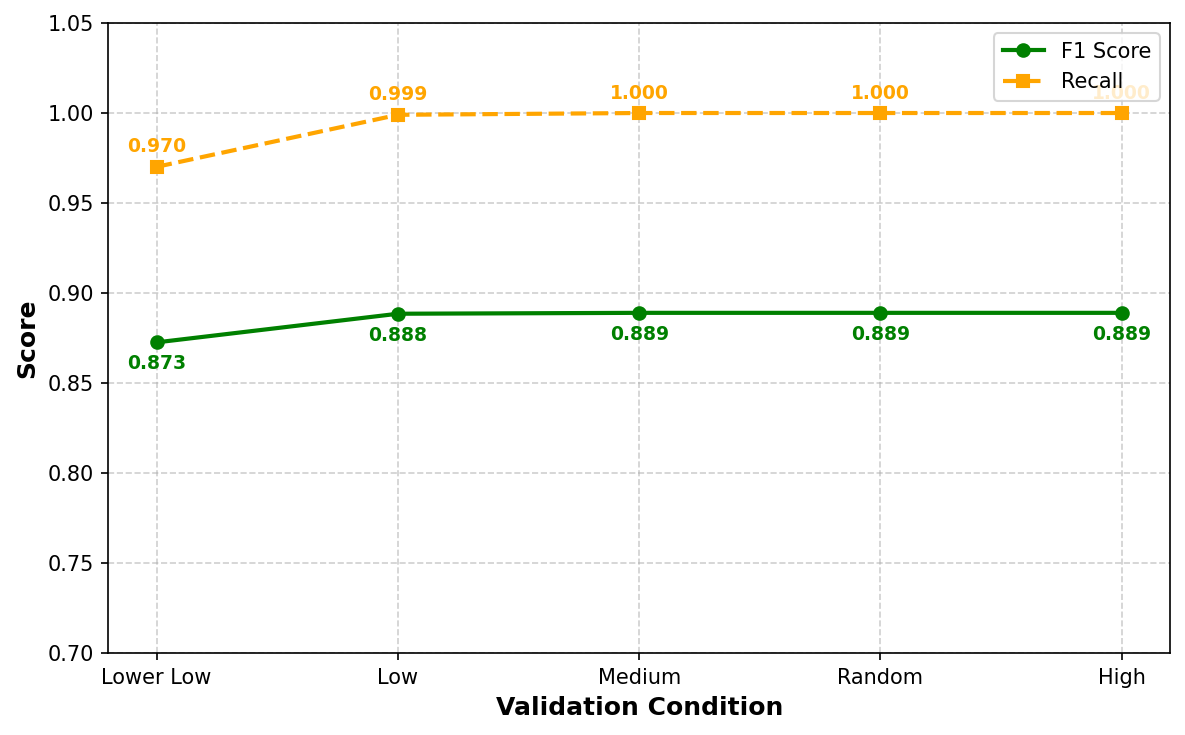

In [31]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.8726, 0.8885, 0.8890, 0.8890, 0.8890]
recalls   = [0.9701, 0.9990, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5), dpi=150)

# Plot F1 Score (green solid line)
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)

# Plot Recall (orange dashed line)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values neatly
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
    plt.text(i, rec + 0.008, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.70, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)

# Move legend to top-right to avoid overlap
plt.legend(fontsize=10, loc='upper right', frameon=True, shadow=False)

# Tight layout to ensure annotations fit
plt.tight_layout()

plt.show()

In [34]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Lower Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Lower Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.08it/s]


Total validation segments loaded: 3311


Formatting segments: 100%|██████████| 3311/3311 [00:00<00:00, 8507.87it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 11.99it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9598
F1 Score:  0.9361
Precision: 0.9250
Recall:    0.9475

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 54               | 975              


{'accuracy': 0.959830866807611,
 'f1': 0.9361497839654345,
 'precision': 0.9250474383301708,
 'recall': 0.9475218658892128}

In [35]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Low"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Low


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.08it/s]


Total validation segments loaded: 3311


Formatting segments: 100%|██████████| 3311/3311 [00:00<00:00, 8330.57it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 11.94it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9758
F1 Score:  0.9625
Precision: 0.9286
Recall:    0.9990

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 1                | 1028             


{'accuracy': 0.9758381153729991,
 'f1': 0.9625468164794008,
 'precision': 0.928635953026197,
 'recall': 0.9990281827016521}

In [36]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Medium"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Medium


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.06it/s]


Total validation segments loaded: 3311


Formatting segments: 100%|██████████| 3311/3311 [00:00<00:00, 8451.00it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 11.88it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9761
F1 Score:  0.9630
Precision: 0.9287
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 0                | 1029             


{'accuracy': 0.9761401389308366,
 'f1': 0.9630322882545624,
 'precision': 0.9287003610108303,
 'recall': 1.0}

In [37]:
TIME_GAP_TEST = 100.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Random"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/Random


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.07it/s]


Total validation segments loaded: 3309


Formatting segments: 100%|██████████| 3309/3309 [00:00<00:00, 8172.74it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 11.88it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9761
F1 Score:  0.9630
Precision: 0.9286
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2203             | 79               
Actual Positive: 0                | 1027             


{'accuracy': 0.9761257177394983,
 'f1': 0.9629629629629629,
 'precision': 0.9285714285714286,
 'recall': 1.0}

In [38]:
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/High"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/Test/Kia/High


Processing validation files: 100%|██████████| 4/4 [00:03<00:00,  1.10it/s]


Total validation segments loaded: 3154


Formatting segments: 100%|██████████| 3154/3154 [00:00<00:00, 7533.28it/s]


Running inference on validation data...


Inference: 100%|██████████| 198/198 [00:16<00:00, 11.86it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9673
F1 Score:  0.9501
Precision: 0.9050
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2070             | 103              
Actual Positive: 0                | 981              


{'accuracy': 0.9673430564362714,
 'f1': 0.9501210653753026,
 'precision': 0.9049815498154982,
 'recall': 1.0}

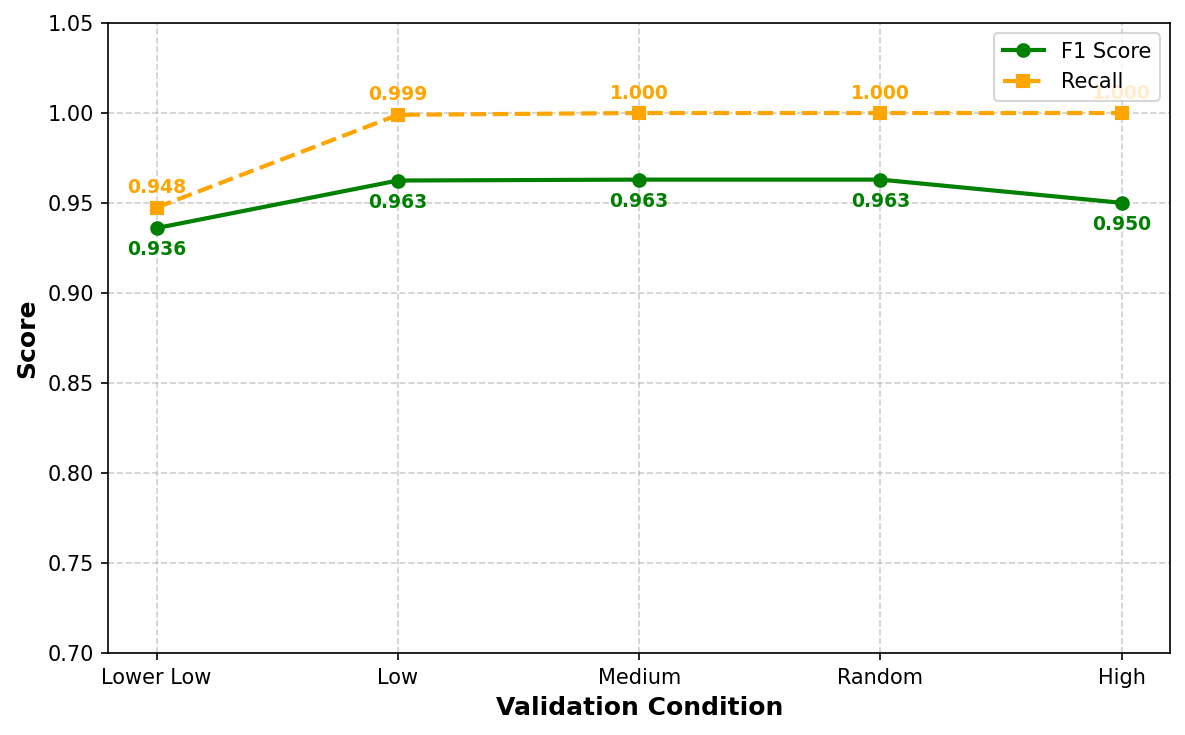

In [39]:
# Labels and values
labels = ['Lower Low', 'Low', 'Medium', 'Random', 'High']
f1_scores = [0.9361, 0.9625, 0.9630, 0.9630, 0.9501]
recalls   = [0.9475, 0.9990, 1.0000, 1.0000, 1.0000]

# Create figure
plt.figure(figsize=(8, 5), dpi=150)

# Plot F1 Score (green solid line)
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)

# Plot Recall (orange dashed line)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Annotate values neatly
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
    plt.text(i, rec + 0.008, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.70, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)

# Move legend to top-right to avoid overlap
plt.legend(fontsize=10, loc='upper right', frameon=True, shadow=False)

# Tight layout to ensure annotations fit
plt.tight_layout()

plt.show()

In [40]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 160.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Forester


Processing validation files: 100%|██████████| 6/6 [00:03<00:00,  1.74it/s]


Total validation segments loaded: 2770


Formatting segments: 100%|██████████| 2770/2770 [00:00<00:00, 8442.30it/s]


Running inference on validation data...


Inference: 100%|██████████| 174/174 [00:14<00:00, 12.11it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9632
F1 Score:  0.8886
Precision: 0.7996
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2261             | 102              
Actual Positive: 0                | 407              


{'accuracy': 0.9631768953068592,
 'f1': 0.888646288209607,
 'precision': 0.7996070726915521,
 'recall': 1.0}

In [41]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 105.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Gen


Processing validation files:  33%|███▎      | 1/3 [00:03<00:07,  3.73s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files:  67%|██████▋   | 2/3 [00:08<00:04,  4.34s/it]/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/utils.py:91: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
Processing validation files: 100%|██████████| 3/3 [00:11<00:00,  3.82s/it]


Total validation segments loaded: 5179


Formatting segments: 100%|██████████| 5179/5179 [00:00<00:00, 6894.47it/s]


Running inference on validation data...


Inference: 100%|██████████| 324/324 [00:27<00:00, 11.89it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9369
F1 Score:  0.8934
Precision: 0.8169
Recall:    0.9856

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 3482             | 307              
Actual Positive: 20               | 1370             


{'accuracy': 0.9368603977601854,
 'f1': 0.8933811542223671,
 'precision': 0.8169350029815146,
 'recall': 0.9856115107913669}

In [42]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 125.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Kia


Processing validation files: 100%|██████████| 4/4 [00:37<00:00,  9.29s/it]


Total validation segments loaded: 4231


Formatting segments: 100%|██████████| 4231/4231 [00:00<00:00, 6734.49it/s]


Running inference on validation data...


Inference: 100%|██████████| 265/265 [00:22<00:00, 11.91it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9752
F1 Score:  0.9678
Precision: 0.9994
Recall:    0.9382

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2548             | 1                
Actual Positive: 104              | 1578             


{'accuracy': 0.9751831718269912,
 'f1': 0.9678012879484821,
 'precision': 0.999366687777074,
 'recall': 0.9381688466111772}

In [43]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 130.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sonata


Processing validation files: 100%|██████████| 4/4 [00:32<00:00,  8.01s/it]


Total validation segments loaded: 3702


Formatting segments: 100%|██████████| 3702/3702 [00:00<00:00, 7240.64it/s]


Running inference on validation data...


Inference: 100%|██████████| 232/232 [00:19<00:00, 11.95it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9900
F1 Score:  0.9878
Precision: 1.0000
Recall:    0.9760

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 2161             | 0                
Actual Positive: 37               | 1504             


{'accuracy': 0.9900054024851431,
 'f1': 0.9878489326765189,
 'precision': 1.0,
 'recall': 0.9759896171317326}

In [44]:
# --- 10. Evaluate a Specific Checkpoint ---
# The path you provided is used here
TIME_GAP_TEST = 130.0
VALIDATION_DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil"
checkpoint_to_evaluate = "/home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental"

print(f"\n--- Evaluating specific checkpoint: {checkpoint_to_evaluate} ---")
evaluate_model(
    model_path=checkpoint_to_evaluate,
    validation_data_directory=VALIDATION_DATA_DIRECTORY, # From your script's config
    time_gap=TIME_GAP_TEST                             # From your script's config
)


--- Evaluating specific checkpoint: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---

--- Starting Evaluation of Model: /home/lisa/Arupreza/UIDS-II/SFTSrc/bert/TrainSil/mobilebert-can-attack-classifier-experimental ---
Loading fine-tuned model and tokenizer...
Loading validation data from: /home/lisa/Arupreza/UIDS-II/Split_data/OtherLAB/Sil


Processing validation files: 100%|██████████| 5/5 [00:04<00:00,  1.05it/s]


Total validation segments loaded: 3300


Formatting segments: 100%|██████████| 3300/3300 [00:00<00:00, 5579.95it/s]


Running inference on validation data...


Inference: 100%|██████████| 207/207 [00:17<00:00, 11.94it/s]


Calculating metrics...

=== Validation Results ===
Accuracy:  0.9615
F1 Score:  0.9583
Precision: 0.9199
Recall:    1.0000

=== Confusion Matrix ===
               Predicted Negative | Predicted Positive
Actual Negative: 1714             | 127              
Actual Positive: 0                | 1459             


{'accuracy': 0.9615151515151515,
 'f1': 0.9582922824302135,
 'precision': 0.9199243379571248,
 'recall': 1.0}

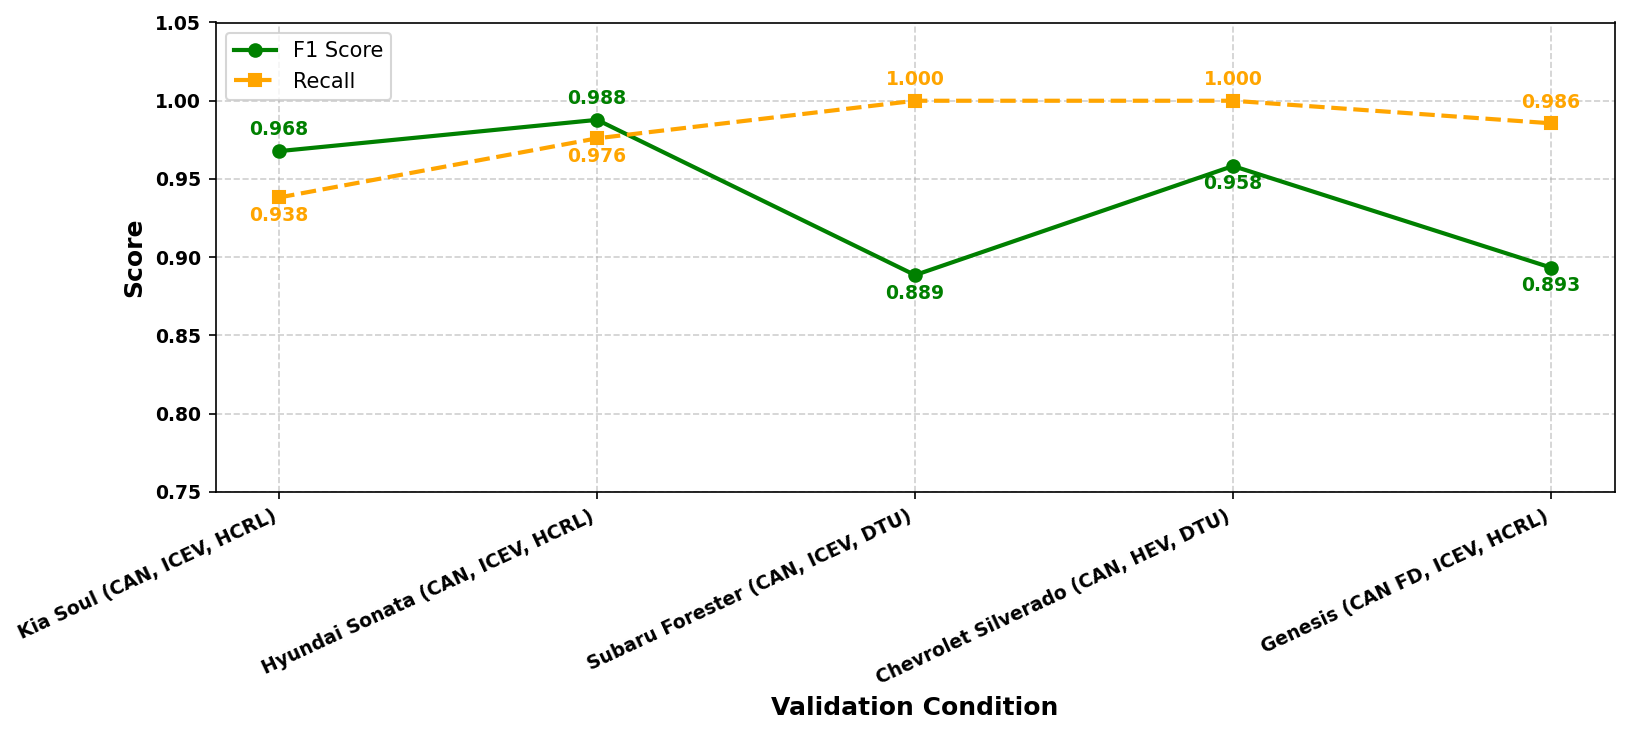

In [45]:
# Labels and values
labels = [
    'Kia Soul (CAN, ICEV, HCRL)',
    'Hyundai Sonata (CAN, ICEV, HCRL)',
    'Subaru Forester (CAN, ICEV, DTU)',
    'Chevrolet Silverado (CAN, HEV, DTU)',
    'Genesis (CAN FD, ICEV, HCRL)'
]
f1_scores = [0.9678, 0.9878, 0.8886, 0.9583, 0.8934]
recalls =   [0.9382, 0.9760, 1.0000, 1.0000, 0.9856]

# Create figure
plt.figure(figsize=(11, 5), dpi=150)

# Plot both F1 and Recall
plt.plot(labels, f1_scores, marker='o', color='green', label='F1 Score', linewidth=2)
plt.plot(labels, recalls, marker='s', color='orange', label='Recall', linewidth=2, linestyle='--')

# Dynamic annotation placement (prevents overlap)
for i, (f1, rec) in enumerate(zip(f1_scores, recalls)):
    # If F1 < Recall → F1 below, Recall above
    if f1 < rec:
        plt.text(i, f1 - 0.015, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
        plt.text(i, rec + 0.010, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')
    else:
        # If F1 > Recall → F1 above, Recall below
        plt.text(i, f1 + 0.010, f"{f1:.3f}", ha='center', fontsize=9, color='green', fontweight='bold')
        plt.text(i, rec - 0.015, f"{rec:.3f}", ha='center', fontsize=9, color='orange', fontweight='bold')

# Labels and formatting
plt.xlabel("Validation Condition", fontsize=12, fontweight='bold')
plt.ylabel("Score", fontsize=12, fontweight='bold')
plt.ylim(0.75, 1.05)
plt.yticks(np.arange(0.75, 1.05, 0.05), fontsize=9, fontweight='bold')
plt.xticks(rotation=25, ha='right', fontsize=9, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

plt.show()